PROPÓSITO DEL ANÁLISIS ESPACIOTEMPORAL
Pregunta Principal de Investigación:
¿Cómo se manifestó geográfica y temporalmente el impacto de la inteligencia artificial en el mercado laboral tech global entre 2020-2025?

OBJETIVOS ESPECÍFICOS:
1. TEMPORAL:

Cuantificar la magnitud y velocidad del cambio salarial post-IA (2023-2025)
Identificar si existe autocorrelación en los cambios salariales entre países
Determinar si el crecimiento del mercado tech sigue un patrón predecible o aleatorio

2. ESPACIAL:

Mapear qué regiones del mundo experimentaron el mayor impacto salarial
Identificar clusters geográficos de alta concentración de empleos tech
Visualizar la distribución global de la "riqueza tech" post-IA

3. ESPACIOTEMPORAL (INTEGRACIÓN):

Detectar si existe un patrón de "difusión geográfica" del impacto IA (¿qué países fueron early adopters?)
Analizar si el crecimiento en una región predice crecimiento en regiones vecinas (lead/lag)
Determinar si hay correlación entre proximidad geográfica y similitud en evolución salarial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, adfuller
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/projectU2.csv')
df['work_year'] = pd.to_numeric(df['work_year'])

def classify_ai_period(year):
    if year <= 2022:
        return 'Pre-IA (2020-2022)'
    else:
        return 'Post-IA (2023-2025)'

df['ai_period'] = df['work_year'].apply(classify_ai_period)

print("Dataset cargado exitosamente")
print(f"Dimensiones: {df.shape}")
print(f"\nPeriodos de IA:\n{df['ai_period'].value_counts().sort_index()}")
print(f"\nAnos disponibles: {sorted(df['work_year'].unique())}")

Dataset cargado exitosamente
Dimensiones: (65117, 23)

Periodos de IA:
ai_period
Post-IA (2023-2025)    62840
Pre-IA (2020-2022)      2277
Name: count, dtype: int64

Anos disponibles: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


### CREAR SERIES TEMPORALES APILADAS POR PAIS

In [3]:
# Seleccionar top 30 paises por volumen de datos
top_countries = df['employee_country_name'].value_counts().head(30).index.tolist()
df_top = df[df['employee_country_name'].isin(top_countries)].copy()

# Crear series temporales por pais
country_year_salary = df_top.groupby(['employee_country_name', 'work_year']).agg({
    'salary_in_usd': ['mean', 'count']
}).reset_index()

country_year_salary.columns = ['country', 'year', 'mean_salary', 'count']

# Filtrar paises con datos en al menos 4 años
country_counts = country_year_salary.groupby('country')['year'].count()
valid_countries = country_counts[country_counts >= 4].index.tolist()
country_year_salary = country_year_salary[country_year_salary['country'].isin(valid_countries)]

print(f"\nPaises con datos en 4+ años: {len(valid_countries)}")
print(f"Total de observaciones pais-año: {len(country_year_salary)}")

# Calcular retornos por pais
country_year_salary = country_year_salary.sort_values(['country', 'year'])
country_year_salary['returns'] = country_year_salary.groupby('country')['mean_salary'].pct_change() * 100

# Serie apilada para ACF
stacked_returns = country_year_salary['returns'].dropna()

print(f"\nObservaciones para ACF (series apiladas): {len(stacked_returns)}")


Paises con datos en 4+ años: 24
Total de observaciones pais-año: 134

Observaciones para ACF (series apiladas): 110


### SERIES TEMPORALES AGREGADAS GLOBALES

In [4]:
yearly_metrics = df.groupby('work_year').agg({
    'salary_in_usd': ['mean', 'median', 'count'],
    'employee_country_name': 'nunique'
}).reset_index()

yearly_metrics.columns = ['year', 'mean_salary', 'median_salary', 'job_count', 'country_count']

# Calcular proporciones por año
exp_level_year = df.groupby(['work_year', 'experience_level']).size().unstack(fill_value=0)
exp_level_year_pct = exp_level_year.div(exp_level_year.sum(axis=1), axis=0) * 100

remote_year = df.groupby(['work_year', 'remote_ratio']).size().unstack(fill_value=0)
remote_year_pct = remote_year.div(remote_year.sum(axis=1), axis=0) * 100

category_year = df.groupby(['work_year', 'category']).size().reset_index(name='count')

print("\nMetricas anuales globales:")
print(yearly_metrics)


Metricas anuales globales:
   year    mean_salary  median_salary  job_count  country_count
0  2020  102997.914634        96099.0        246             36
1  2021  102939.766082        92500.0        684             57
2  2022  130948.367483       126080.0       1347             51
3  2023  156580.828089       147100.0       3496             36
4  2024  146934.886433       137000.0      24338             64
5  2025  144329.133863       135482.0      35006             54


### VISUALIZACION: LINE GRAPHS (4 metricas clave)

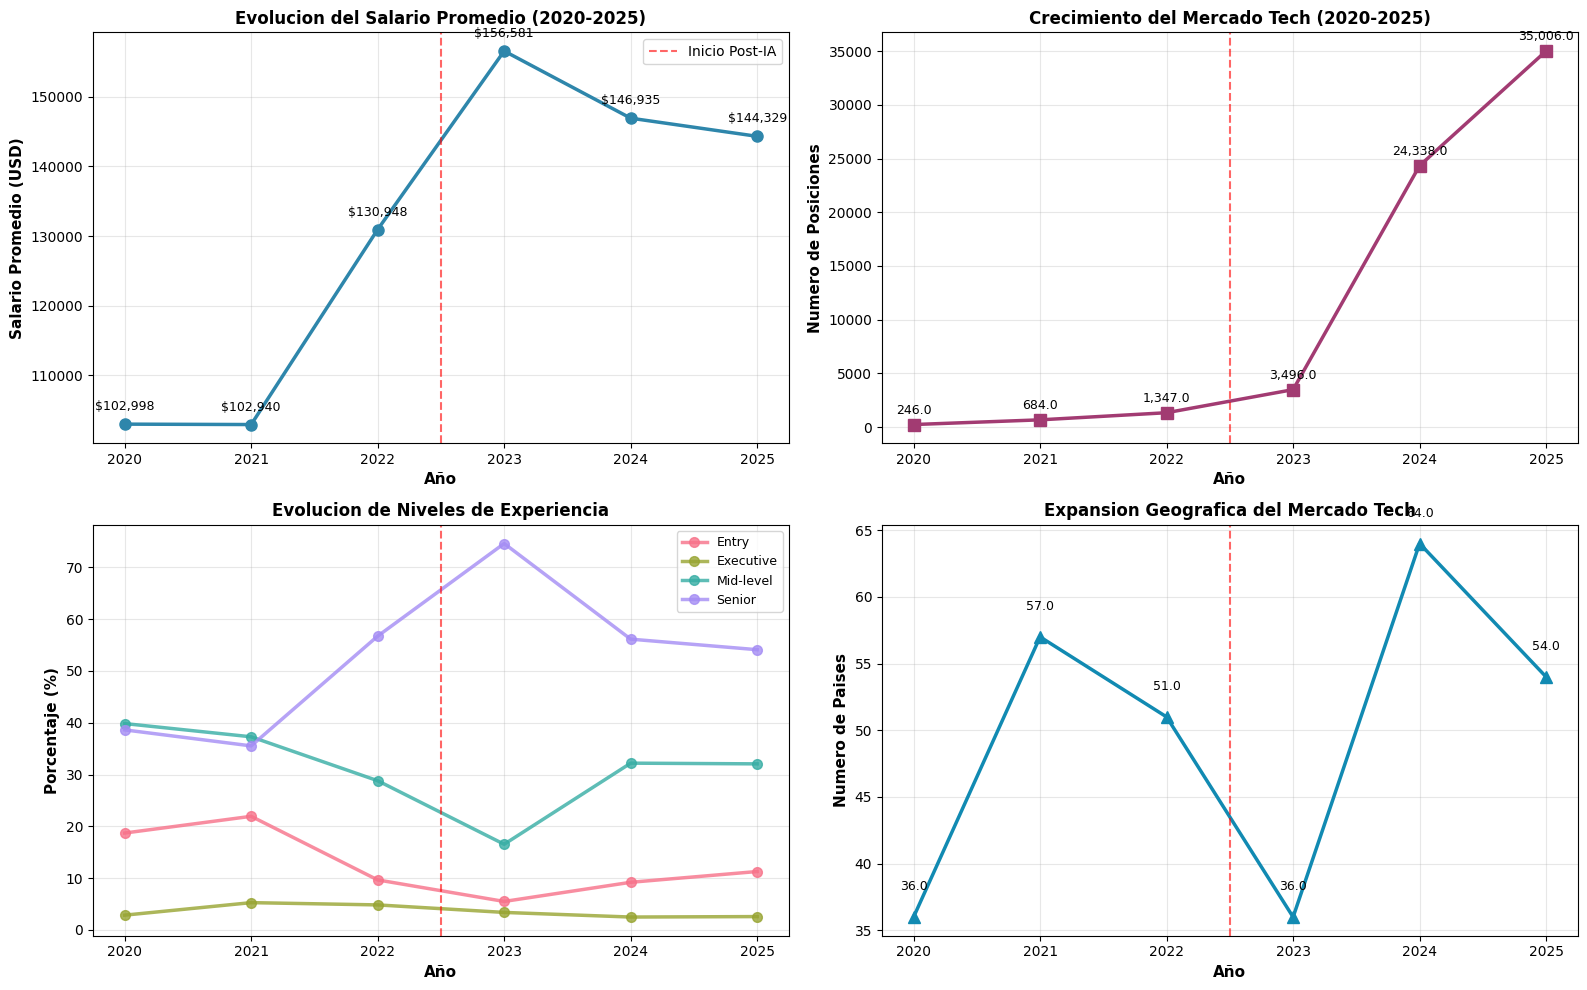

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 3.1 Salario promedio
axes[0, 0].plot(yearly_metrics['year'], yearly_metrics['mean_salary'], 
                marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
axes[0, 0].axvline(2022.5, color='red', linestyle='--', alpha=0.6, label='Inicio Post-IA')
axes[0, 0].set_xlabel('Año', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Salario Promedio (USD)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Evolucion del Salario Promedio (2020-2025)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
for i, row in yearly_metrics.iterrows():
    axes[0, 0].text(row['year'], row['mean_salary'] + 2000, f"${row['mean_salary']:,.0f}", 
                    ha='center', fontsize=9)

# 3.2 Numero de empleos tech
axes[0, 1].plot(yearly_metrics['year'], yearly_metrics['job_count'], 
                marker='s', linewidth=2.5, markersize=8, color='#A23B72')
axes[0, 1].axvline(2022.5, color='red', linestyle='--', alpha=0.6)
axes[0, 1].set_xlabel('Año', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Numero de Posiciones', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Crecimiento del Mercado Tech (2020-2025)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
for i, row in yearly_metrics.iterrows():
    axes[0, 1].text(row['year'], row['job_count'] + 1000, f"{row['job_count']:,}", 
                    ha='center', fontsize=9)

# 3.3 Proporcion de niveles de experiencia (todos los disponibles)
exp_levels = exp_level_year_pct.columns.tolist()
colors = sns.color_palette("husl", len(exp_levels))
exp_level_map = {'EN': 'Entry', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'}

for i, level in enumerate(exp_levels):
    label = exp_level_map.get(level, level)
    axes[1, 0].plot(exp_level_year_pct.index, exp_level_year_pct[level], 
                    marker='o', linewidth=2.5, markersize=7, 
                    color=colors[i], label=label, alpha=0.8)

axes[1, 0].axvline(2022.5, color='red', linestyle='--', alpha=0.6)
axes[1, 0].set_xlabel('Año', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Porcentaje (%)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Evolucion de Niveles de Experiencia', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='best', fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# 3.4 Numero de paises activos
axes[1, 1].plot(yearly_metrics['year'], yearly_metrics['country_count'], 
                marker='^', linewidth=2.5, markersize=8, color='#118AB2')
axes[1, 1].axvline(2022.5, color='red', linestyle='--', alpha=0.6)
axes[1, 1].set_xlabel('Año', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Numero de Paises', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Expansion Geografica del Mercado Tech', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
for i, row in yearly_metrics.iterrows():
    axes[1, 1].text(row['year'], row['country_count'] + 2, f"{row['country_count']}", 
                    ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### TEST DE RANDOM WALK EN SERIES APILADAS

In [6]:
print("\n" + "="*70)
print("TEST DE RANDOM WALK - SERIES APILADAS POR PAIS")
print("="*70)

# Test en salarios apilados (niveles)
stacked_salaries = country_year_salary['mean_salary'].dropna()
adf_salary = adfuller(stacked_salaries, autolag='AIC')

print(f"\n4.1 TEST EN SALARIOS (series apiladas - {len(stacked_salaries)} obs):")
print(f"ADF Statistic: {adf_salary[0]:.4f}")
print(f"p-value: {adf_salary[1]:.4f}")
print(f"Lags usados: {adf_salary[2]}")
print(f"Numero de observaciones: {adf_salary[3]}")
print("\nValores criticos:")
for key, value in adf_salary[4].items():
    print(f"  {key}: {value:.4f}")

if adf_salary[1] > 0.05:
    print("\nCONCLUSION: NO se rechaza H0 -> Los salarios siguen un RANDOM WALK")
    print("Serie NO estacionaria - tendencia temporal presente")
else:
    print("\nCONCLUSION: Se rechaza H0 -> Los salarios NO siguen un random walk")
    print("Serie estacionaria")

# Test en retornos apilados
adf_returns = adfuller(stacked_returns, autolag='AIC')

print(f"\n4.2 TEST EN RETORNOS (series apiladas - {len(stacked_returns)} obs):")
print(f"ADF Statistic: {adf_returns[0]:.4f}")
print(f"p-value: {adf_returns[1]:.4f}")
print(f"Lags usados: {adf_returns[2]}")
print(f"Numero de observaciones: {adf_returns[3]}")
print("\nValores criticos:")
for key, value in adf_returns[4].items():
    print(f"  {key}: {value:.4f}")

if adf_returns[1] > 0.05:
    print("\nCONCLUSION: NO se rechaza H0 -> Los retornos siguen un random walk")
else:
    print("\nCONCLUSION: Se rechaza H0 -> Los retornos SON ESTACIONARIOS")
    print("No hay autocorrelacion significativa - variaciones son aleatorias")



TEST DE RANDOM WALK - SERIES APILADAS POR PAIS

4.1 TEST EN SALARIOS (series apiladas - 134 obs):
ADF Statistic: -2.9269
p-value: 0.0423
Lags usados: 9
Numero de observaciones: 124

Valores criticos:
  1%: -3.4842
  5%: -2.8851
  10%: -2.5794

CONCLUSION: Se rechaza H0 -> Los salarios NO siguen un random walk
Serie estacionaria

4.2 TEST EN RETORNOS (series apiladas - 110 obs):
ADF Statistic: -3.7999
p-value: 0.0029
Lags usados: 3
Numero de observaciones: 106

Valores criticos:
  1%: -3.4936
  5%: -2.8892
  10%: -2.5815

CONCLUSION: Se rechaza H0 -> Los retornos SON ESTACIONARIOS
No hay autocorrelacion significativa - variaciones son aleatorias


### ANALISIS DE AUTOCORRELACION (ACF) - SERIES APILADAS

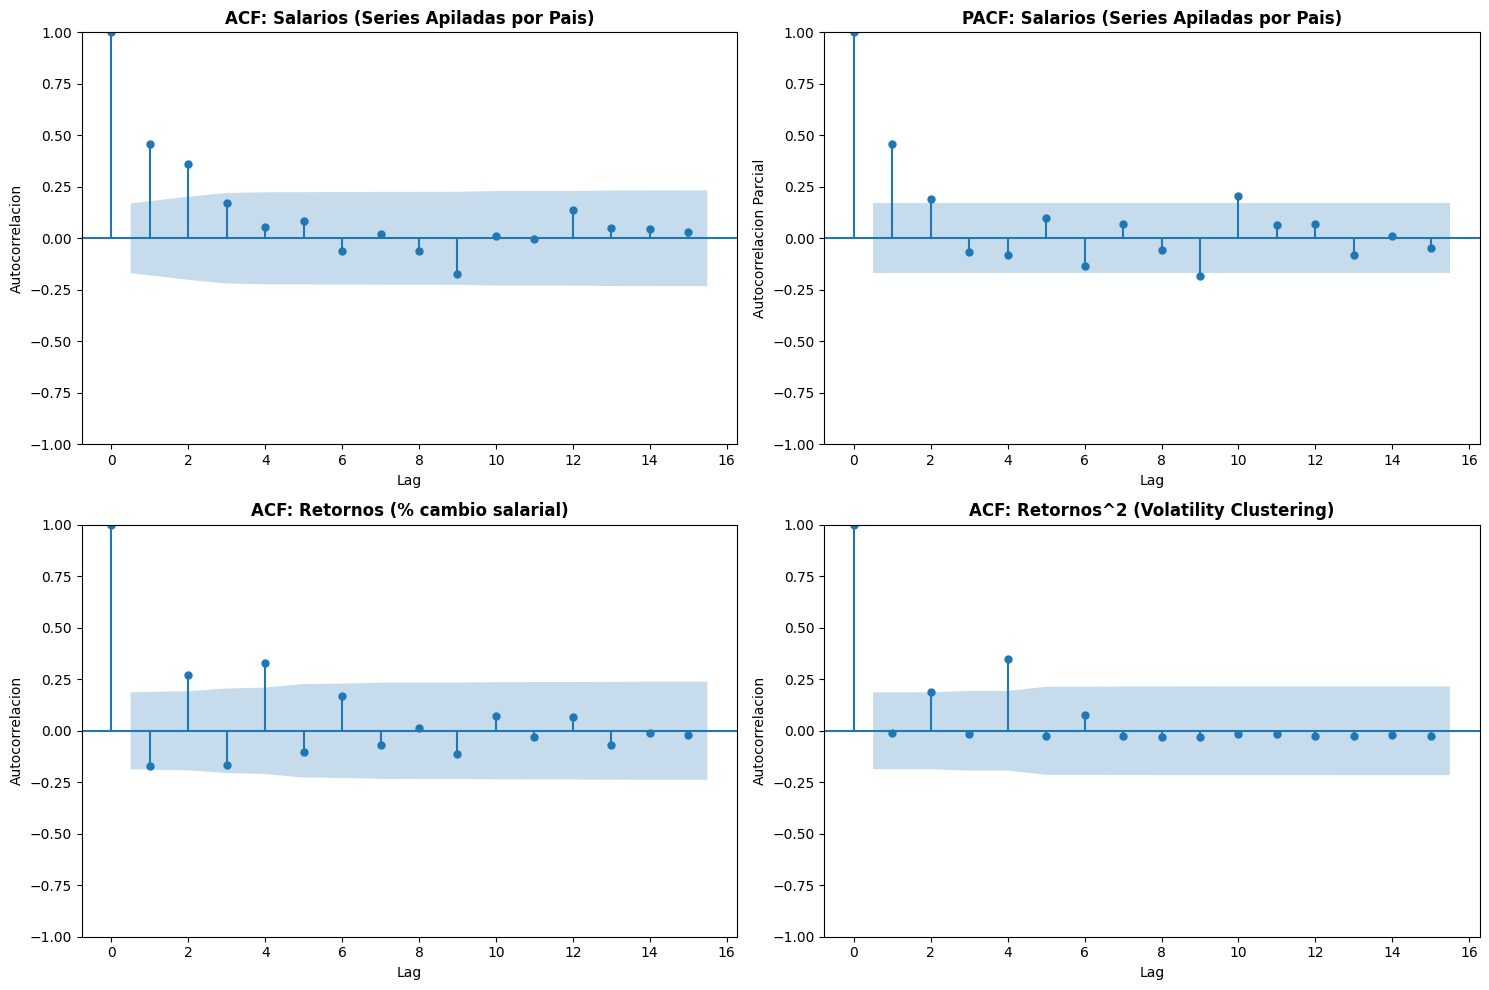


INTERPRETACION DE ACF - SERIES APILADAS

5.1 ACF DE SALARIOS (primeros 5 lags):
  Lag 1: 0.4586
  Lag 2: 0.3624
  Lag 3: 0.1736
  Lag 4: 0.0533
  Lag 5: 0.0842

5.2 ACF DE RETORNOS (primeros 5 lags):
  Lag 1: -0.1714
  Lag 2: 0.2703
  Lag 3: -0.1677
  Lag 4: 0.3299
  Lag 5: -0.1039

Bandas de confianza (95%): +/- 0.1869


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 5.1 ACF de Salarios apilados
plot_acf(stacked_salaries, lags=15, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title('ACF: Salarios (Series Apiladas por Pais)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Lag', fontsize=10)
axes[0, 0].set_ylabel('Autocorrelacion', fontsize=10)

# 5.2 PACF de Salarios apilados
plot_pacf(stacked_salaries, lags=15, ax=axes[0, 1], alpha=0.05, method='ywm')
axes[0, 1].set_title('PACF: Salarios (Series Apiladas por Pais)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Lag', fontsize=10)
axes[0, 1].set_ylabel('Autocorrelacion Parcial', fontsize=10)

# 5.3 ACF de Retornos apilados
plot_acf(stacked_returns, lags=15, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF: Retornos (% cambio salarial)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Lag', fontsize=10)
axes[1, 0].set_ylabel('Autocorrelacion', fontsize=10)

# 5.4 ACF de Retornos^2 (volatility clustering)
returns_squared = stacked_returns ** 2
plot_acf(returns_squared, lags=15, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF: Retornos^2 (Volatility Clustering)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Lag', fontsize=10)
axes[1, 1].set_ylabel('Autocorrelacion', fontsize=10)

plt.tight_layout()
plt.show()

# Calcular ACF manualmente
acf_salary = acf(stacked_salaries, nlags=10, fft=False)
acf_returns = acf(stacked_returns, nlags=10, fft=False)

print("\n" + "="*70)
print("INTERPRETACION DE ACF - SERIES APILADAS")
print("="*70)
print("\n5.1 ACF DE SALARIOS (primeros 5 lags):")
for i in range(1, 6):
    print(f"  Lag {i}: {acf_salary[i]:.4f}")

print("\n5.2 ACF DE RETORNOS (primeros 5 lags):")
for i in range(1, 6):
    print(f"  Lag {i}: {acf_returns[i]:.4f}")

n = len(stacked_returns)
conf_bound = 1.96 / np.sqrt(n)
print(f"\nBandas de confianza (95%): +/- {conf_bound:.4f}")

### STREAMGRAPH: EVOLUCION DE CATEGORIAS

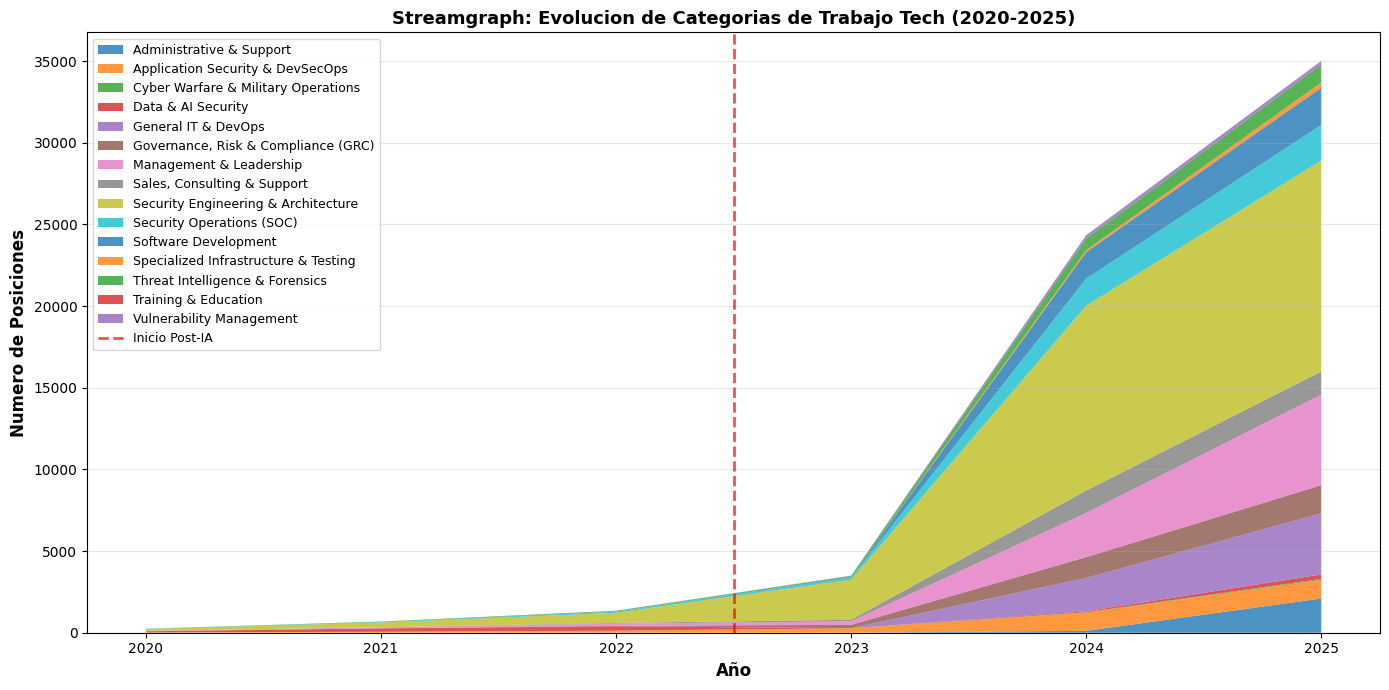

In [8]:
category_year_pivot = category_year.pivot(index='work_year', columns='category', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
ax.stackplot(category_year_pivot.index, 
             *[category_year_pivot[col] for col in category_year_pivot.columns],
             labels=category_year_pivot.columns,
             alpha=0.8)
ax.axvline(2022.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Inicio Post-IA')
ax.set_xlabel('Año', fontsize=12, fontweight='bold')
ax.set_ylabel('Numero de Posiciones', fontsize=12, fontweight='bold')
ax.set_title('Streamgraph: Evolucion de Categorias de Trabajo Tech (2020-2025)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### COMPARACION PRE-IA vs POST-IA

In [9]:
print("\n" + "="*70)
print("COMPARACION ESTADISTICA: PRE-IA vs POST-IA")
print("="*70)

pre_ia = df[df['ai_period'] == 'Pre-IA (2020-2022)']['salary_in_usd']
post_ia = df[df['ai_period'] == 'Post-IA (2023-2025)']['salary_in_usd']

t_stat, p_value = stats.ttest_ind(post_ia, pre_ia)

print(f"\n7.1 SALARIOS:")
print(f"Pre-IA:  Media = ${pre_ia.mean():,.2f}, Mediana = ${pre_ia.median():,.2f}, n = {len(pre_ia)}")
print(f"Post-IA: Media = ${post_ia.mean():,.2f}, Mediana = ${post_ia.median():,.2f}, n = {len(post_ia)}")
print(f"\nCambio porcentual: {((post_ia.mean() - pre_ia.mean()) / pre_ia.mean() * 100):.2f}%")
print(f"\nT-test: t = {t_stat:.4f}, p-value = {p_value:.4e}")
if p_value < 0.001:
    print("Diferencia ALTAMENTE SIGNIFICATIVA (p < 0.001)")

print("\n7.2 NUMERO DE POSICIONES:")
pre_jobs = len(pre_ia)
post_jobs = len(post_ia)
print(f"Pre-IA:  {pre_jobs:,} posiciones")
print(f"Post-IA: {post_jobs:,} posiciones")
print(f"Crecimiento: {((post_jobs - pre_jobs) / pre_jobs * 100):.2f}%")


COMPARACION ESTADISTICA: PRE-IA vs POST-IA

7.1 SALARIOS:
Pre-IA:  Media = $119,515.04, Mediana = $112,900.00, n = 2277
Post-IA: Media = $146,019.95, Mediana = $137,000.00, n = 62840

Cambio porcentual: 22.18%

T-test: t = 19.9074, p-value = 6.4181e-88
Diferencia ALTAMENTE SIGNIFICATIVA (p < 0.001)

7.2 NUMERO DE POSICIONES:
Pre-IA:  2,277 posiciones
Post-IA: 62,840 posiciones
Crecimiento: 2659.77%


### SLOPEGRAPH: COMPARACION 2020 vs 2025 POR PAIS

In [10]:
!!pip install adjustText

['Requirement already satisfied: adjustText in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (1.3.0)',
 'Requirement already satisfied: numpy in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from adjustText) (2.3.3)',
 'Requirement already satisfied: matplotlib in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from adjustText) (3.10.6)',
 'Requirement already satisfied: scipy in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from adjustText) (1.16.2)',
 'Requirement already satisfied: contourpy>=1.0.1 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from matplotlib->adjustText) (1.3.3)',
 'Requirement already satisfied: cycler>=0.10 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from matplotlib->adjustText) (0.12.1)',
 'Requirement already

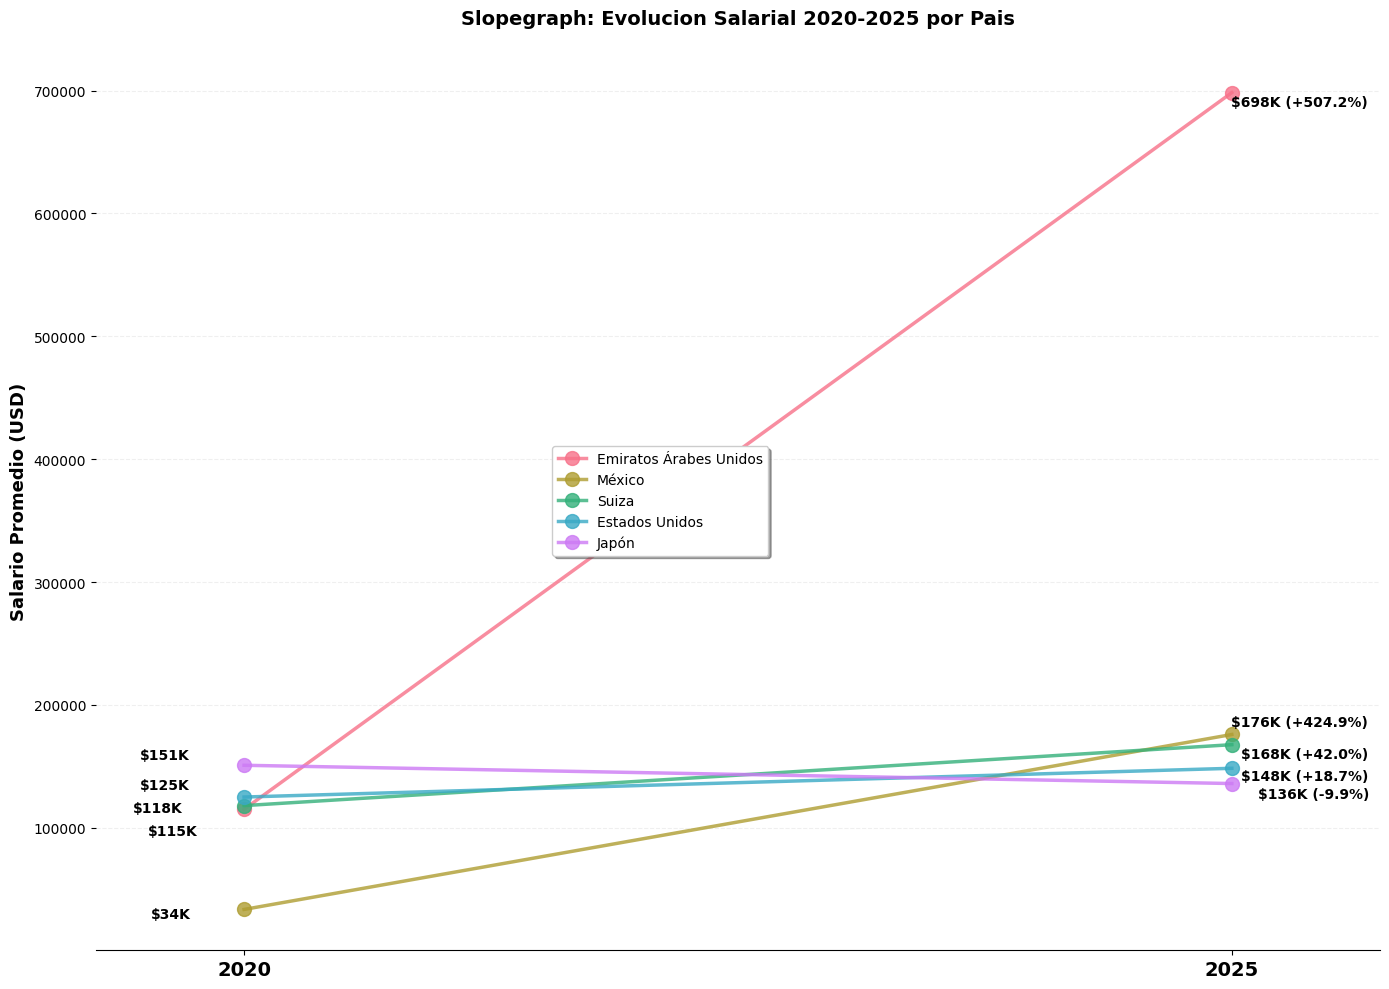


SLOPEGRAPH: TOP 5 PAISES
Emiratos Árabes Unidos: $115,000 -> $698,326 (+507.2%)
México: $33,511 -> $175,912 (+424.9%)
Suiza: $118,008 -> $167,613 (+42.0%)
Estados Unidos: $124,991 -> $148,392 (+18.7%)
Japón: $150,844 -> $135,981 (-9.9%)


In [11]:

from adjustText import adjust_text  # ### AÑADIDO 1: Importar la librería ###


# Obtener salarios por pais en 2020 y 2025
salary_2020 = df[df['work_year'] == 2020].groupby('employee_country_name')['salary_in_usd'].mean()
salary_2025 = df[df['work_year'] == 2025].groupby('employee_country_name')['salary_in_usd'].mean()

# Paises presentes en ambos años
common_countries = salary_2020.index.intersection(salary_2025.index)

if len(common_countries) >= 5:
    # Calcular crecimiento
    growth = ((salary_2025[common_countries] - salary_2020[common_countries]) / salary_2020[common_countries] * 100)
    
    # Top 5 paises por salario promedio en 2025
    top_countries = salary_2025[common_countries].nlargest(5).index
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Colores diferentes para cada linea
    colors = sns.color_palette("husl", len(top_countries))
    
    # ### AÑADIDO 2: Listas para guardar las etiquetas de texto ###
    texts_2020 = []
    texts_2025 = []
    
    for idx, country in enumerate(top_countries):
        y_2020 = salary_2020[country]
        y_2025 = salary_2025[country]
        change_pct = growth[country]
        
        # Linea con color unico
        ax.plot([0, 1], [y_2020, y_2025], 
                marker='o', markersize=10, linewidth=2.5, 
                alpha=0.8, color=colors[idx], label=country)
        
        # ### AÑADIDO 3: Guardar la etiqueta en la lista ###
        # Etiqueta 2020 (izquierda)
        texts_2020.append(
            ax.text(-0.05, y_2020, f"${y_2020/1000:.0f}K", 
                    ha='right', va='center', fontsize=10, fontweight='bold')
        )
        
        # ### AÑADIDO 4: Guardar la etiqueta en la lista ###
        # Etiqueta 2025 (derecha) con cambio porcentual
        texts_2025.append(
            ax.text(1.05, y_2025, f"${y_2025/1000:.0f}K ({change_pct:+.1f}%)", 
                    ha='left', va='center', fontsize=10, fontweight='bold')
        )
    
    ax.set_xlim(-0.15, 1.15)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['2020', '2025'], fontsize=14, fontweight='bold')
    ax.set_ylabel('Salario Promedio (USD)', fontsize=13, fontweight='bold')
    ax.set_title('Slopegraph: Evolucion Salarial 2020-2025 por Pais', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.2, axis='y', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Leyenda (se mantiene como en tu original)
    ax.legend(loc='center left', bbox_to_anchor=(0.35, 0.5), 
              fontsize=10, frameon=True, shadow=True)
    
    # ### AÑADIDO 5: Llamar a la función para ajustar el texto ###
    adjust_text(texts_2020)
    adjust_text(texts_2025)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("SLOPEGRAPH: TOP 5 PAISES") # Ajustado de 8 a 5 para que coincida con el código
    print("="*70)
    for country in top_countries:
        change = growth[country]
        print(f"{country}: ${salary_2020[country]:,.0f} -> ${salary_2025[country]:,.0f} ({change:+.1f}%)")
else:
    print("\nNOTA: No hay suficientes paises con datos en 2020 y 2025 para Slopegraph")

### HEATMAP: SALARIO PROMEDIO POR AÑO Y EXPERIENCE LEVEL

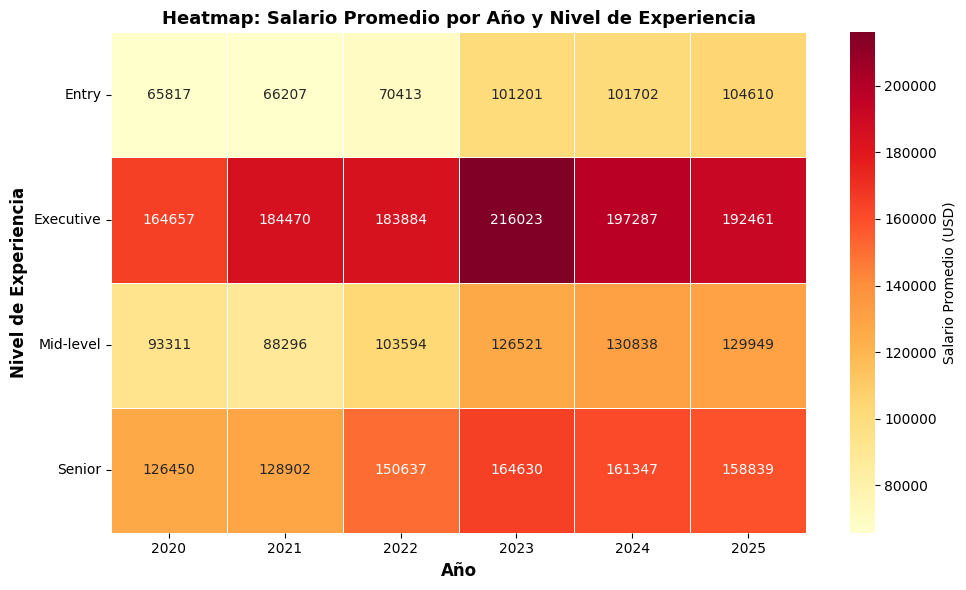


HEATMAP: SALARIOS POR EXPERIENCIA Y AÑO
experience_level             EN             EX             MI             SE
work_year                                                                   
2020               65816.934783  164657.285714   93311.428571  126450.389474
2021               66207.206667  184470.055556   88296.243137  128902.283951
2022               70413.407692  183883.584615  103594.131443  150637.109948
2023              101201.223958  216022.805085  126520.916955  164630.429064
2024              101702.389361  197286.514901  130837.824888  161346.626263
2025              104609.751394  192460.701111  129948.617537  158839.241947


In [12]:
salary_year_exp = df.groupby(['work_year', 'experience_level'])['salary_in_usd'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(salary_year_exp.T, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Salario Promedio (USD)'}, ax=ax, linewidths=0.5)
ax.set_xlabel('Año', fontsize=12, fontweight='bold')
ax.set_ylabel('Nivel de Experiencia', fontsize=12, fontweight='bold')
ax.set_title('Heatmap: Salario Promedio por Año y Nivel de Experiencia', 
             fontsize=13, fontweight='bold')

exp_level_labels = {'EN': 'Entry', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'}
current_labels = ax.get_yticklabels()
new_labels = [exp_level_labels.get(label.get_text(), label.get_text()) for label in current_labels]
ax.set_yticklabels(new_labels, rotation=0)

plt.tight_layout()
plt.savefig('05_heatmap_salario_experiencia.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("HEATMAP: SALARIOS POR EXPERIENCIA Y AÑO")
print("="*70)
print(salary_year_exp)

### WATERFALL CHART: CAMBIO EN POSICIONES POR EXPERIENCE LEVEL

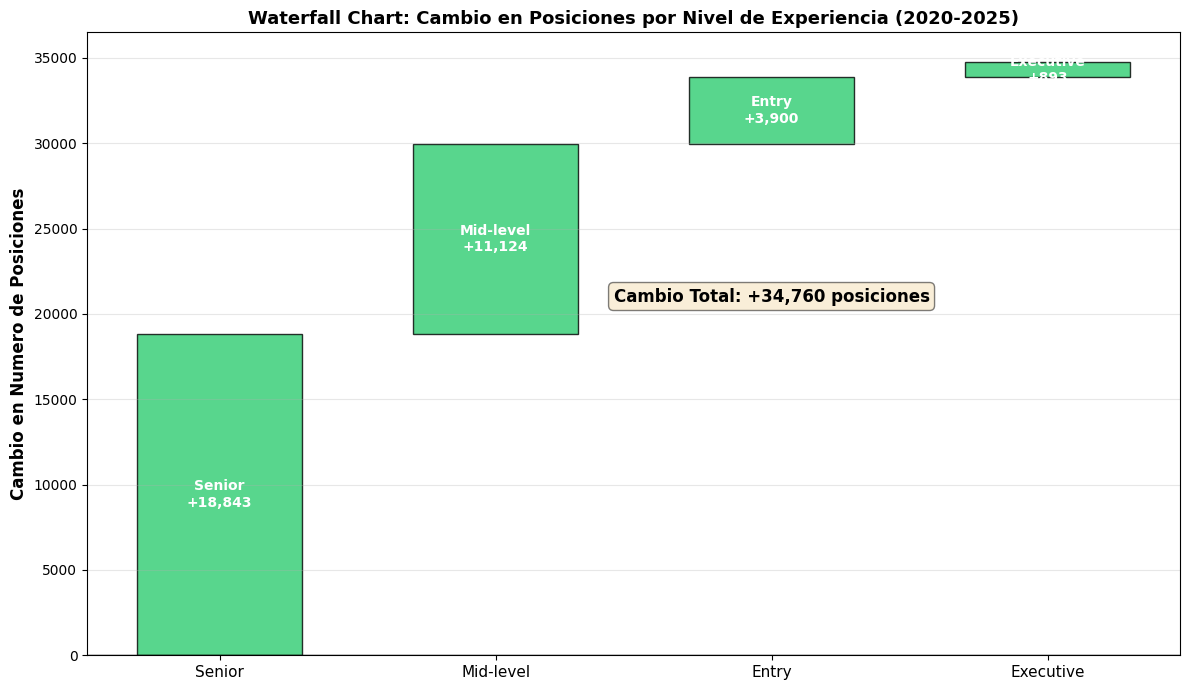


WATERFALL: CAMBIO EN POSICIONES POR NIVEL (2020-2025)
Senior: +18,843 posiciones
Mid-level: +11,124 posiciones
Entry: +3,900 posiciones
Executive: +893 posiciones

Cambio Total: +34,760 posiciones


In [13]:
exp_2020 = df[df['work_year'] == 2020]['experience_level'].value_counts()
exp_2025 = df[df['work_year'] == 2025]['experience_level'].value_counts()

all_levels = sorted(set(exp_2020.index) | set(exp_2025.index))
changes = {}
for level in all_levels:
    val_2020 = exp_2020.get(level, 0)
    val_2025 = exp_2025.get(level, 0)
    changes[level] = val_2025 - val_2020

changes_sorted = dict(sorted(changes.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(12, 7))

cumulative = 0
x_pos = 0
colors_waterfall = []
positions = []
values_for_plot = []

for level, change in changes_sorted.items():
    if change > 0:
        colors_waterfall.append('#2ecc71')
    else:
        colors_waterfall.append('#e74c3c')
    
    ax.bar(x_pos, change, bottom=cumulative, width=0.6, 
           color=colors_waterfall[-1], alpha=0.8, edgecolor='black')
    
    label_name = exp_level_labels.get(level, level)
    ax.text(x_pos, cumulative + change/2, f"{label_name}\n{change:+,}", 
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    positions.append(label_name)
    cumulative += change
    x_pos += 1

ax.axhline(0, color='black', linewidth=1, linestyle='-')
ax.set_xticks(range(len(positions)))
ax.set_xticklabels(positions, fontsize=11)
ax.set_ylabel('Cambio en Numero de Posiciones', fontsize=12, fontweight='bold')
ax.set_title('Waterfall Chart: Cambio en Posiciones por Nivel de Experiencia (2020-2025)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

total_change = sum(changes.values())
ax.text(len(positions)/2, max(changes.values())*1.1, 
        f"Cambio Total: {total_change:+,} posiciones", 
        ha='center', fontsize=12, fontweight='bold', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("WATERFALL: CAMBIO EN POSICIONES POR NIVEL (2020-2025)")
print("="*70)
for level, change in changes_sorted.items():
    label_name = exp_level_labels.get(level, level)
    print(f"{label_name}: {change:+,} posiciones")
print(f"\nCambio Total: {total_change:+,} posiciones")


### CROSS-CORRELATION FUNCTION (CCF) ENTRE PAISES

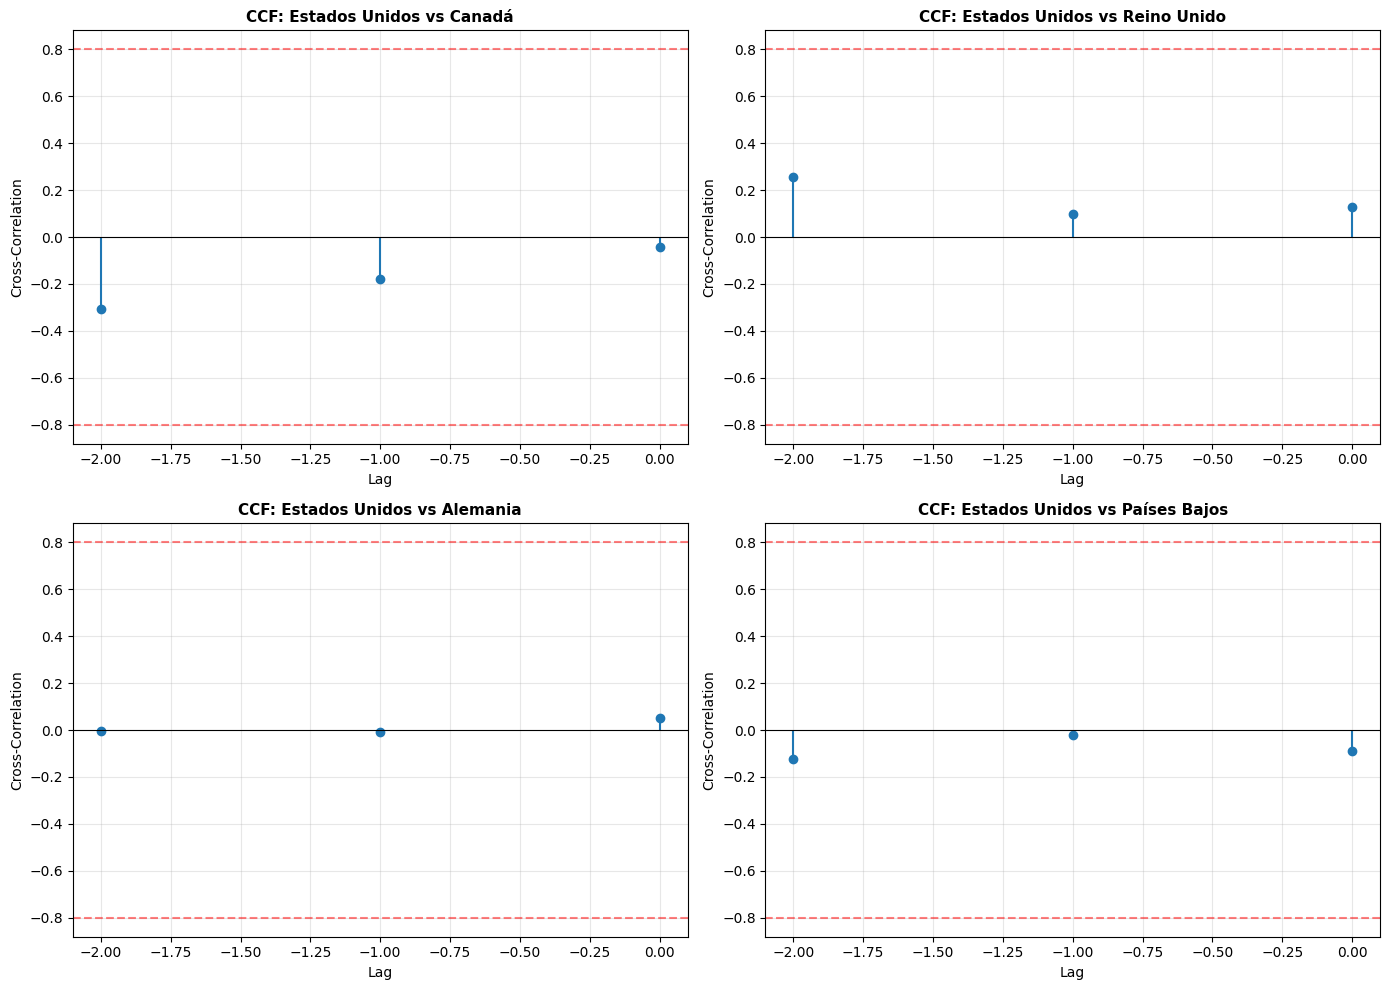


CROSS-CORRELATION FUNCTION: Estados Unidos vs OTROS PAISES
Interpretacion:
- Lag negativo: Pais de referencia predice al otro pais
- Lag positivo: Otro pais predice al pais de referencia
- Lag 0: Correlacion contemporanea

7.2 NUMERO DE POSICIONES:
Pre-IA:  2,277 posiciones
Post-IA: 62,840 posiciones
Crecimiento: 2659.77%


In [14]:
from statsmodels.tsa.stattools import ccf

# Seleccionar top 5 paises por volumen
top_5_countries = df['employee_country_name'].value_counts().head(5).index.tolist()

# Crear series temporales para cada pais
country_series = {}
for country in top_5_countries:
    country_data = country_year_salary[country_year_salary['country'] == country].sort_values('year')
    if len(country_data) >= 4:
        country_series[country] = country_data.set_index('year')['mean_salary']

if len(country_series) >= 2:
    reference_country = top_5_countries[0]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    plot_idx = 0
    for i, country in enumerate(top_5_countries[1:5]):
        if country in country_series and reference_country in country_series:
            series1 = country_series[reference_country]
            series2 = country_series[country]
            
            common_years = series1.index.intersection(series2.index)
            if len(common_years) >= 4:
                s1 = series1[common_years].values
                s2 = series2[common_years].values
                
                ccf_values = ccf(s1, s2, adjusted=False)
                lags = np.arange(-len(ccf_values)//2 + 1, len(ccf_values)//2 + 1)
                ccf_values_centered = np.concatenate([ccf_values[len(ccf_values)//2:], 
                                                      ccf_values[:len(ccf_values)//2]])
                
                axes[plot_idx].stem(lags[:len(lags)//2], ccf_values_centered[:len(lags)//2], 
                                   basefmt=' ', linefmt='C0-', markerfmt='C0o')
                
                conf_bound = 1.96 / np.sqrt(len(common_years))
                axes[plot_idx].axhline(conf_bound, color='red', linestyle='--', alpha=0.5)
                axes[plot_idx].axhline(-conf_bound, color='red', linestyle='--', alpha=0.5)
                axes[plot_idx].axhline(0, color='black', linewidth=0.8)
                
                axes[plot_idx].set_xlabel('Lag', fontsize=10)
                axes[plot_idx].set_ylabel('Cross-Correlation', fontsize=10)
                axes[plot_idx].set_title(f'CCF: {reference_country} vs {country}', 
                                        fontsize=11, fontweight='bold')
                axes[plot_idx].grid(True, alpha=0.3)
                
                plot_idx += 1
    
    for idx in range(plot_idx, 4):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print(f"CROSS-CORRELATION FUNCTION: {reference_country} vs OTROS PAISES")
    print("="*70)
    print("Interpretacion:")
    print("- Lag negativo: Pais de referencia predice al otro pais")
    print("- Lag positivo: Otro pais predice al pais de referencia")
    print("- Lag 0: Correlacion contemporanea")
else:
    print("\nNOTA: No hay suficientes paises con datos para CCF")

print("\n7.2 NUMERO DE POSICIONES:")
pre_jobs = len(pre_ia)
post_jobs = len(post_ia)
print(f"Pre-IA:  {pre_jobs:,} posiciones")
print(f"Post-IA: {post_jobs:,} posiciones")
print(f"Crecimiento: {((post_jobs - pre_jobs) / pre_jobs * 100):.2f}%")

### ANALISIS ESPACIAL - MAPAS GEOGRAFICOS

In [15]:
!!pip install geopandas folium

['Requirement already satisfied: geopandas in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (1.1.1)',
 'Requirement already satisfied: folium in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (0.20.0)',
 'Requirement already satisfied: numpy>=1.24 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from geopandas) (2.3.3)',
 'Requirement already satisfied: pyogrio>=0.7.2 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from geopandas) (0.11.1)',
 'Requirement already satisfied: packaging in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from geopandas) (25.0)',
 'Requirement already satisfied: pandas>=2.0.0 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from geopandas) (2.3.2)',
 'Requirement already satisfied: pyproj>=3.5.0 in c:\\users\\yuse

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection
import warnings
warnings.filterwarnings('ignore')

In [33]:
df = pd.read_csv('data/projectU2.csv')
df['work_year'] = pd.to_numeric(df['work_year'])

def classify_ai_period(year):
    if year <= 2022:
        return 'Pre-IA'
    else:
        return 'Post-IA'

df['ai_period'] = df['work_year'].apply(classify_ai_period)

print("="*70)
print("FASE 2: ANALISIS ESPACIAL - MAPAS GEOGRAFICOS")
print("="*70)
print(f"Total de registros: {len(df):,}")
print(f"Paises unicos (empleados): {df['employee_country_name'].nunique()}")
print(f"Paises unicos (empresas): {df['company_country_name'].nunique()}")

# Cargar mapa mundial
try:
    # legacy: works if geopandas bundled datasets are available (<1.0)
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
except Exception:
    # GeoPandas >=1.0 removed the bundled dataset. Fallback: read Natural Earth GeoJSON from GitHub mirror
    # (or download the shapefile from naturalearthdata.com and read locally)
    url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
    world = gpd.read_file(url)

FASE 2: ANALISIS ESPACIAL - MAPAS GEOGRAFICOS
Total de registros: 65,117
Paises unicos (empleados): 95
Paises unicos (empresas): 92


### CHOROPLETH MAP: CRECIMIENTO SALARIAL POR PAIS

In [22]:
!!pip install folium pycountry

['Requirement already satisfied: folium in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (0.20.0)',
 'Collecting pycountry',
 '  Downloading pycountry-24.6.1-py3-none-any.whl.metadata (12 kB)',
 'Requirement already satisfied: branca>=0.6.0 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from folium) (0.8.2)',
 'Requirement already satisfied: jinja2>=2.9 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from folium) (3.1.6)',
 'Requirement already satisfied: numpy in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from folium) (2.3.3)',
 'Requirement already satisfied: requests in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from folium) (2.32.5)',
 'Requirement already satisfied: xyzservices in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages 

In [29]:
!!pip install pandas geopandas folium mapclassify pycountry

['Requirement already satisfied: pandas in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (2.3.2)',
 'Requirement already satisfied: geopandas in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (1.1.1)',
 'Requirement already satisfied: folium in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (0.20.0)',
 'Requirement already satisfied: mapclassify in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (2.10.0)',
 'Requirement already satisfied: pycountry in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (24.6.1)',
 'Requirement already satisfied: numpy>=1.26.0 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from pandas) (2.3.3)',
 'Requirement already satisfied: python-dateutil>=2.8.2 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv

In [25]:
!!pip install "folium>=0.12" matplotlib mapclassify

['Requirement already satisfied: folium>=0.12 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (0.20.0)',
 'Requirement already satisfied: matplotlib in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (3.10.6)',
 'Requirement already satisfied: mapclassify in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (2.10.0)',
 'Requirement already satisfied: branca>=0.6.0 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from folium>=0.12) (0.8.2)',
 'Requirement already satisfied: jinja2>=2.9 in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from folium>=0.12) (3.1.6)',
 'Requirement already satisfied: numpy in c:\\users\\yusel\\documents\\github\\visualization-tools-ix\\.venv\\lib\\site-packages (from folium>=0.12) (2.3.3)',
 'Requirement already satisfied: requests in c:\\users\\yusel\\document

In [36]:
from IPython.display import display
print("="*70)
print("1. CHOROPLETH MAP: CRECIMIENTO SALARIAL POR PAIS (INTERACTIVO)")
print("="*70)

# --- 3. Cálculo de crecimiento (Tu código) ---
salary_by_country_period = df.groupby(['employee_country_name', 'ai_period'])['salary_in_usd'].mean().unstack()

if 'Pre-IA' in salary_by_country_period.columns and 'Post-IA' in salary_by_country_period.columns:
    salary_by_country_period['growth_pct'] = (
        (salary_by_country_period['Post-IA'] - salary_by_country_period['Pre-IA']) / 
        salary_by_country_period['Pre-IA'] * 100
    )
    
    salary_growth = salary_by_country_period[['growth_pct']].dropna().reset_index()
    salary_growth = salary_growth.rename(columns={'employee_country_name': 'country'})
    
    # --- 4. Solución Robusta: Mapeo a ISO_A3 ---
    def get_iso_a3(country_name):
        # Correcciones manuales para nombres comunes que fallan
        if country_name == "United States": return "USA"
        if country_name == "Russian Federation": return "RUS"
        if "Iran" in country_name: return "IRN"
        try:
            # Usar búsqueda "fuzzy" para encontrar el país
            return pycountry.countries.search_fuzzy(country_name)[0].alpha_3
        except LookupError:
            # print(f"Código no encontrado para: {country_name}") # Descomenta para depurar
            return None

    print("Asignando códigos ISO_A3 a los datos de salarios...")
    salary_growth['ISO_A3'] = salary_growth['country'].apply(get_iso_a3)
    
    # --- 5. Preparar GeoDataFrame 'world' ---
    # Filtrar Antártida para un mejor zoom
    world = world[world['NAME_EN'] != 'Antarctica']

    print("Uniendo datos de salarios al mapa mundial...")
    # Unir usando el código ISO_A3 (mucho más fiable)
    world_data = world.merge(salary_growth, on='ISO_A3', how='left')
    
    # --- 6. Generar Mapa Interactivo ---
    print("Generando mapa interactivo...")
    
    # Redondear el porcentaje para un tooltip más limpio
    world_data['growth_pct_display'] = world_data['growth_pct'].round(1)
    
    m = world_data.explore(
        column='growth_pct',         # Columna para colorear
        cmap='RdYlGn',             # Paleta de colores (Rojo-Amarillo-Verde)
        tooltip=['NAME_EN', 'growth_pct_display'], # Info al pasar el mouse
        popup=True,                # Muestra info al hacer clic
        legend_kwds={
            'caption': 'Crecimiento Salarial (%)', # Título de la leyenda
            'scale': True
        },
        missing_kwds={             # Países sin datos
            'color': 'lightgray',
            'label': 'Sin datos'
        },
        tiles='CartoDB positron',  # Estilo del mapa base (limpio)
        name="Crecimiento Salarial"
    )
    
    # --- 7. Mostrar el mapa en el Notebook ---
    # Al ser 'm' la última expresión, Colab/Jupyter lo mostrará
    
    # Top 10 paises con mayor crecimiento
    top_growth = salary_growth.sort_values('growth_pct', ascending=False).head(10)
    # ... todo tu código de cálculo ...
    print("\nTop 10 paises con mayor crecimiento salarial:")
    for idx, row in top_growth.iterrows():
        print(f"  {row['country']}: {row['growth_pct']:+.1f}%")

    display(m) # Opcionalmente, puedes incluso borrar esta línea
    
# Si 'm' no se muestra automáticamente (a veces pasa si hay prints después),
# añade 'm' o 'display(m)' en una celda completamente nueva después de esta.
# Para este código, he movido el print ANTES de mostrar 'm'.

1. CHOROPLETH MAP: CRECIMIENTO SALARIAL POR PAIS (INTERACTIVO)
Asignando códigos ISO_A3 a los datos de salarios...
Uniendo datos de salarios al mapa mundial...
Generando mapa interactivo...

Top 10 paises con mayor crecimiento salarial:
  México: +658.9%
  Turquía: +538.9%
  Honduras: +475.0%
  Costa Rica: +344.2%
  Malta: +256.3%
  Colombia: +225.0%
  Emiratos Árabes Unidos: +212.5%
  Rumania: +173.9%
  Luxemburgo: +137.0%
  Finlandia: +117.8%


### PROPORTIONAL SYMBOL MAP: TOTAL DE EMPLEOS POR UBICACION

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

print("\n" + "="*70)
print("2. PROPORTIONAL SYMBOL MAP: TOTAL DE EMPLEOS TECH (INTERACTIVO)")
print("="*70)

# Contar empleos por país
jobs_by_country = df.groupby('employee_country_name').size().reset_index(name='job_count')

# Obtener coordenadas (usar las del dataset)
country_coords = df.groupby('employee_country_name').agg({
    'employee_latitude': 'first',
    'employee_longitude': 'first'
}).reset_index()

jobs_by_country = jobs_by_country.merge(country_coords, on='employee_country_name')

# ⚠️ LIMPIEZA: Eliminar valores nulos o fuera de rango
jobs_by_country = jobs_by_country.dropna(subset=['employee_latitude', 'employee_longitude'])
jobs_by_country = jobs_by_country[
    (jobs_by_country['employee_latitude'] >= -90) & 
    (jobs_by_country['employee_latitude'] <= 90) &
    (jobs_by_country['employee_longitude'] >= -180) & 
    (jobs_by_country['employee_longitude'] <= 180)
]

# Verificar datos
print(f"\nPaíses válidos después de limpieza: {len(jobs_by_country)}")
print("\nMuestra de coordenadas:")
print(jobs_by_country[['employee_country_name', 'employee_latitude', 'employee_longitude', 'job_count']].head(10))

# Normalizar tamaños (ajustado para mejor visualización)
jobs_by_country['circle_size'] = np.log1p(jobs_by_country['job_count']) * 8

# Crear mapa interactivo
fig = go.Figure()

fig.add_trace(go.Scattergeo(
    lon=jobs_by_country['employee_longitude'],
    lat=jobs_by_country['employee_latitude'],
    text=jobs_by_country['employee_country_name'],
    mode='markers',
    marker=dict(
        size=jobs_by_country['circle_size'],
        color=jobs_by_country['job_count'],
        colorscale='YlOrRd',
        showscale=True,
        colorbar=dict(
            title="Empleos Tech",
            thickness=15,
            len=0.6,
        ),
        line=dict(width=1, color='black'),
        sizemin=4,  # Tamaño mínimo
        opacity=0.8
    ),
    hovertemplate='<b>%{text}</b><br>' +
                  'Empleos: %{marker.color:,}<br>' +
                  '<extra></extra>',
))

fig.update_layout(
    title={
        'text': 'Concentración de Empleos Tech por País',
        'font': {'size': 20, 'family': 'Arial, sans-serif'},
        'x': 0.5,
        'xanchor': 'center'
    },
    geo=dict(
        projection_type='equirectangular',  # ✅ Proyección plana (sin distorsión)
        showland=True,
        landcolor='#e5e5e5',
        coastlinecolor='white',
        coastlinewidth=1.5,
        showocean=True,
        oceancolor='#d4e6f1',
        showcountries=True,
        countrycolor='white',
        countrywidth=0.8,
        bgcolor='#f0f0f0',
        resolution=50,
        scope='world'  # Vista mundial completa
    ),
    height=700,
    width=1400,
    hovermode='closest',
    paper_bgcolor='white',
    plot_bgcolor='white'
)


# Top 10 países
top_countries_jobs = jobs_by_country.nlargest(10, 'job_count')
print("\n" + "="*70)
print("Top 10 países con más empleos tech:")
print("="*70)
for idx, row in top_countries_jobs.iterrows():
    print(f"  {row['employee_country_name']}: {row['job_count']:,} empleos")


2. PROPORTIONAL SYMBOL MAP: TOTAL DE EMPLEOS TECH (INTERACTIVO)

Países válidos después de limpieza: 95

Muestra de coordenadas:
  employee_country_name  employee_latitude  employee_longitude  job_count
0            Afganistán          33.939110           67.709950          3
1               Albania          41.153330           20.168331          2
2              Alemania          51.165690           10.451526        479
3        Arabia Saudita          23.885942           45.079163          1
4               Argelia          28.033886            1.659626          1
5             Argentina         -38.416096          -63.616673          8
6               Armenia          40.069100           45.038190          2
7             Australia         -25.274399          133.775130        298
8               Austria          47.516230           14.550072        169
9            Azerbaiyán          40.143105           47.576927          2



Top 10 países con más empleos tech:
  Estados Unidos: 58,909 empleos
  Canadá: 2,132 empleos
  Reino Unido: 1,353 empleos
  Alemania: 479 empleos
  Países Bajos: 303 empleos
  Australia: 298 empleos
  Austria: 169 empleos
  Eslovaquia: 147 empleos
  Francia: 121 empleos
  España: 96 empleos


### FLOW MAP: MIGRACION DE TALENTO (Employee vs Company Location)

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

print("\n" + "="*70)
print("3. FLOW MAP: MIGRACION DE TALENTO TECH (INTERACTIVO)")
print("="*70)

# Identificar casos donde employee_country != company_country
df_flow = df[df['employee_country_name'] != df['company_country_name']].copy()

print(f"Trabajadores remotos internacionales: {len(df_flow):,} ({len(df_flow)/len(df)*100:.1f}%)")

# Crear pares origen-destino
flow_counts = df_flow.groupby(['employee_country_name', 'company_country_name']).size().reset_index(name='flow_count')

# Obtener coordenadas
flow_counts = flow_counts.merge(
    df[['employee_country_name', 'employee_latitude', 'employee_longitude']].drop_duplicates(),
    on='employee_country_name'
)
flow_counts = flow_counts.merge(
    df[['company_country_name', 'company_latitude', 'company_longitude']].drop_duplicates(),
    on='company_country_name'
)

# ⚠️ AJUSTE: Reducir el umbral mínimo (antes era 50, ahora 2)
flow_counts = flow_counts[flow_counts['flow_count'] >= 2].copy()

# Tomar top 30 flujos (o todos si hay menos)
n_flows = min(30, len(flow_counts))
flow_counts = flow_counts.nlargest(n_flows, 'flow_count')

print(f"Flujos significativos (2+ personas): {len(flow_counts)}")

# Limpiar coordenadas inválidas
flow_counts = flow_counts.dropna(subset=['employee_latitude', 'employee_longitude', 
                                          'company_latitude', 'company_longitude'])

if len(flow_counts) == 0:
    print("\n⚠️ No hay suficientes flujos para visualizar")
    print("Mostrando distribución de trabajadores remotos:")
    print(df_flow['employee_country_name'].value_counts().head(10))
else:
    # Crear figura
    fig = go.Figure()

    # 1. LÍNEAS DE FLUJO (curvas geodésicas)
    for idx, row in flow_counts.iterrows():
        # Calcular grosor proporcional al flujo
        line_width = np.log1p(row['flow_count']) * 1.5
        
        fig.add_trace(go.Scattergeo(
            lon=[row['employee_longitude'], row['company_longitude']],
            lat=[row['employee_latitude'], row['company_latitude']],
            mode='lines',
            line=dict(
                width=line_width,
                color='rgba(255, 50, 50, 0.5)'
            ),
            hovertemplate=f"<b>{row['employee_country_name']} → {row['company_country_name']}</b><br>" +
                          f"Trabajadores: {row['flow_count']}<br>" +
                          "<extra></extra>",
            showlegend=False
        ))

    # 2. PUNTOS DE ORIGEN (Empleados - Azul)
    employee_locs = flow_counts.groupby(['employee_country_name', 'employee_latitude', 
                                         'employee_longitude'])['flow_count'].sum().reset_index()
    
    fig.add_trace(go.Scattergeo(
        lon=employee_locs['employee_longitude'],
        lat=employee_locs['employee_latitude'],
        mode='markers',
        marker=dict(
            size=np.log1p(employee_locs['flow_count']) * 5 + 8,
            color='#3498db',
            line=dict(width=1.5, color='white'),
            opacity=0.8
        ),
        text=employee_locs['employee_country_name'],
        hovertemplate='<b>%{text}</b> (Origen)<br>' +
                      'Trabajadores salientes: %{marker.size:.0f}<br>' +
                      '<extra></extra>',
        name='Employee Location',
        showlegend=True
    ))

    # 3. PUNTOS DE DESTINO (Empresas - Naranja)
    company_locs = flow_counts.groupby(['company_country_name', 'company_latitude', 
                                        'company_longitude'])['flow_count'].sum().reset_index()
    
    fig.add_trace(go.Scattergeo(
        lon=company_locs['company_longitude'],
        lat=company_locs['company_latitude'],
        mode='markers',
        marker=dict(
            size=np.log1p(company_locs['flow_count']) * 5 + 8,
            color='#f39c12',
            line=dict(width=1.5, color='white'),
            opacity=0.8
        ),
        text=company_locs['company_country_name'],
        hovertemplate='<b>%{text}</b> (Destino)<br>' +
                      'Trabajadores entrantes: %{marker.size:.0f}<br>' +
                      '<extra></extra>',
        name='Company Location',
        showlegend=True
    ))

    # Layout
    fig.update_layout(
        title={
            'text': 'Flow Map: Migración de Talento Tech (Employee → Company)',
            'font': {'size': 20, 'family': 'Arial, sans-serif'},
            'x': 0.5,
            'xanchor': 'center'
        },
        geo=dict(
            projection_type='natural earth',
            showland=True,
            landcolor='#ecf0f1',
            coastlinecolor='white',
            coastlinewidth=1,
            showocean=True,
            oceancolor='#d4e6f1',
            showcountries=True,
            countrycolor='white',
            countrywidth=0.8,
            bgcolor='#f8f9fa',
            resolution=50
        ),
        height=700,
        width=1400,
        hovermode='closest',
        legend=dict(
            x=0.02,
            y=0.98,
            bgcolor='rgba(255,255,255,0.9)',
            bordercolor='black',
            borderwidth=1
        ),
        paper_bgcolor='white'
    )


    # Estadísticas
    print("\n" + "="*70)
    print(f"Top {min(10, len(flow_counts))} flujos migratorios:")
    print("="*70)
    top_flows = flow_counts.nlargest(10, 'flow_count')
    for idx, row in top_flows.iterrows():
        print(f"  {row['employee_country_name']:20} → {row['company_country_name']:20}: {row['flow_count']:3} personas")
    
    print("\n" + "="*70)
    print("Países que más talento exportan:")
    print("="*70)
    export_countries = flow_counts.groupby('employee_country_name')['flow_count'].sum().nlargest(5)
    for country, count in export_countries.items():
        print(f"  {country}: {count} trabajadores")
    
    print("\n" + "="*70)
    print("Países que más talento importan:")
    print("="*70)
    import_countries = flow_counts.groupby('company_country_name')['flow_count'].sum().nlargest(5)
    for country, count in import_countries.items():
        print(f"  {country}: {count} trabajadores")


3. FLOW MAP: MIGRACION DE TALENTO TECH (INTERACTIVO)
Trabajadores remotos internacionales: 145 (0.2%)
Flujos significativos (2+ personas): 21



Top 10 flujos migratorios:
  Canadá               → Estados Unidos      :  12 personas
  India                → Estados Unidos      :   9 personas
  Estados Unidos       → Canadá              :   5 personas
  España               → Estados Unidos      :   5 personas
  Francia              → Estados Unidos      :   5 personas
  Brasil               → Estados Unidos      :   4 personas
  Alemania             → Estados Unidos      :   4 personas
  Grecia               → Estados Unidos      :   3 personas
  Italia               → Estados Unidos      :   3 personas
  Portugal             → Estados Unidos      :   3 personas

Países que más talento exportan:
  Canadá: 12 trabajadores
  India: 11 trabajadores
  Estados Unidos: 7 trabajadores
  España: 5 trabajadores
  Francia: 5 trabajadores

Países que más talento importan:
  Estados Unidos: 62 trabajadores
  Canadá: 5 trabajadores
  Reino Unido: 4 trabajadores
  Alemania: 2 trabajadores
  Noruega: 2 trabajadores


### POINT DISTRIBUTION MAP: CLUSTERING POR RANGO SALARIAL

In [45]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

print("\n" + "="*70)
print("4. POINT DISTRIBUTION MAP: CLUSTERING POR SALARIO (INTERACTIVO)")
print("="*70)

# Crear categorías salariales
df['salary_category'] = pd.cut(df['salary_in_usd'], 
                                bins=[0, 80000, 120000, 160000, np.inf],
                                labels=['<80K', '80K-120K', '120K-160K', '>160K'])

# Limpiar datos inválidos
df_clean = df.dropna(subset=['employee_latitude', 'employee_longitude', 'salary_category'])
df_clean = df_clean[
    (df_clean['employee_latitude'] >= -90) & 
    (df_clean['employee_latitude'] <= 90) &
    (df_clean['employee_longitude'] >= -180) & 
    (df_clean['employee_longitude'] <= 180)
]

# Sample para mejor visualización (ajustable según tu dataset)
sample_size = min(5000, len(df_clean))
df_sample = df_clean.sample(n=sample_size, random_state=42)

print(f"Muestra visualizada: {len(df_sample):,} empleados de {len(df):,} totales")

# Colores por categoría salarial
colors = {
    '<80K': '#3498db',      # Azul
    '80K-120K': '#2ecc71',  # Verde
    '120K-160K': '#f39c12', # Naranja
    '>160K': '#e74c3c'      # Rojo
}

# Crear figura
fig = go.Figure()

# Añadir puntos por cada categoría salarial
for category in ['<80K', '80K-120K', '120K-160K', '>160K']:
    subset = df_sample[df_sample['salary_category'] == category]
    
    if len(subset) > 0:
        fig.add_trace(go.Scattergeo(
            lon=subset['employee_longitude'],
            lat=subset['employee_latitude'],
            mode='markers',
            marker=dict(
                size=6,
                color=colors[category],
                opacity=0.6,
                line=dict(width=0.3, color='white')
            ),
            name=category,
            text=subset['employee_country_name'],
            customdata=np.column_stack((
                subset['salary_in_usd'],
                subset['job_title'],
                subset['experience_level']
            )),
            hovertemplate='<b>%{text}</b><br>' +
                          'Salario: $%{customdata[0]:,.0f}<br>' +
                          'Puesto: %{customdata[1]}<br>' +
                          'Nivel: %{customdata[2]}<br>' +
                          '<extra></extra>'
        ))

# Layout del mapa
fig.update_layout(
    title={
        'text': 'Point Distribution Map: Distribución Global por Rango Salarial',
        'font': {'size': 20, 'family': 'Arial, sans-serif'},
        'x': 0.5,
        'xanchor': 'center'
    },
    geo=dict(
        projection_type='natural earth',
        showland=True,
        landcolor='#ecf0f1',
        coastlinecolor='white',
        coastlinewidth=1,
        showocean=True,
        oceancolor='#d4e6f1',
        showcountries=True,
        countrycolor='white',
        countrywidth=0.8,
        bgcolor='#f8f9fa',
        resolution=50
    ),
    height=700,
    width=1400,
    hovermode='closest',
    legend=dict(
        title=dict(text='Rango Salarial (USD)', font=dict(size=12, family='Arial')),
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.95)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=11)
    ),
    paper_bgcolor='white'
)

# Guardar y mostrar
fig.write_html('11_point_distribution_clustering_interactivo.html')
fig.show()

# Estadísticas por categoría
print("\n" + "="*70)
print("Distribución por rango salarial:")
print("="*70)
salary_dist = df['salary_category'].value_counts().sort_index()
for cat, count in salary_dist.items():
    pct = count / len(df) * 100
    avg_salary = df[df['salary_category'] == cat]['salary_in_usd'].mean()
    print(f"  {cat:12} : {count:6,} empleados ({pct:5.1f}%) | Promedio: ${avg_salary:,.0f}")

print("\n" + "="*70)
print("Top 5 países por categoría salarial:")
print("="*70)
for category in ['<80K', '80K-120K', '120K-160K', '>160K']:
    subset = df[df['salary_category'] == category]
    top_countries = subset['employee_country_name'].value_counts().head(5)
    print(f"\n{category}:")
    for country, count in top_countries.items():
        print(f"  {country:25}: {count:4} empleados")

# Análisis adicional: Salario promedio por país (top 10)
print("\n" + "="*70)
print("Top 10 países por salario promedio:")
print("="*70)
salary_by_country = df.groupby('employee_country_name')['salary_in_usd'].agg(['mean', 'count'])
salary_by_country = salary_by_country[salary_by_country['count'] >= 10]  # Min 10 empleados
salary_by_country = salary_by_country.sort_values('mean', ascending=False).head(10)
for country, row in salary_by_country.iterrows():
    print(f"  {country:25}: ${row['mean']:>10,.0f} (n={row['count']})")


4. POINT DISTRIBUTION MAP: CLUSTERING POR SALARIO (INTERACTIVO)
Muestra visualizada: 5,000 empleados de 65,117 totales



Distribución por rango salarial:
  <80K         :  8,442 empleados ( 13.0%) | Promedio: $63,277
  80K-120K     : 17,200 empleados ( 26.4%) | Promedio: $101,213
  120K-160K    : 16,841 empleados ( 25.9%) | Promedio: $139,920
  >160K        : 22,634 empleados ( 34.8%) | Promedio: $212,803

Top 5 países por categoría salarial:

<80K:
  Estados Unidos           : 5905 empleados
  Reino Unido              :  703 empleados
  Canadá                   :  353 empleados
  Países Bajos             :  184 empleados
  Alemania                 :  153 empleados

80K-120K:
  Estados Unidos           : 15265 empleados
  Canadá                   :  759 empleados
  Reino Unido              :  458 empleados
  Alemania                 :  200 empleados
  Australia                :  107 empleados

120K-160K:
  Estados Unidos           : 15848 empleados
  Canadá                   :  556 empleados
  Reino Unido              :  118 empleados
  Australia                :   90 empleados
  Alemania               

### CARTOGRAM: PAISES REDIMENSIONADOS POR CONTRIBUCION AL MERCADO

In [49]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

print("\n" + "="*70)
print("5. CARTOGRAM: CONTRIBUCION AL MERCADO TECH GLOBAL (INTERACTIVO)")
print("="*70)

# Calcular masa salarial total por país
salary_mass = df.groupby('employee_country_name').agg({
    'salary_in_usd': 'sum',
    'employee_latitude': 'first',
    'employee_longitude': 'first'
}).reset_index()

salary_mass.columns = ['country', 'total_salary_mass', 'latitude', 'longitude']
salary_mass['percentage'] = salary_mass['total_salary_mass'] / salary_mass['total_salary_mass'].sum() * 100
salary_mass['num_employees'] = df.groupby('employee_country_name').size().values

# Limpiar coordenadas inválidas
salary_mass = salary_mass.dropna(subset=['latitude', 'longitude'])
salary_mass = salary_mass[
    (salary_mass['latitude'] >= -90) & 
    (salary_mass['latitude'] <= 90) &
    (salary_mass['longitude'] >= -180) & 
    (salary_mass['longitude'] <= 180)
]

# Top 20 países
top_20 = salary_mass.nlargest(20, 'total_salary_mass')

# ⚠️ AJUSTE DE TAMAÑOS: Usar escala logarítmica y reducir tamaño máximo
top_20['bubble_size'] = np.log1p(top_20['total_salary_mass']) * 2.5  # Reducido de /80 a *2.5

print(f"Visualizando top 20 países de {len(salary_mass)} totales")
print(f"Masa salarial total del mercado: ${salary_mass['total_salary_mass'].sum()/1e9:.2f}B")

# Crear figura
fig = go.Figure()

# Burbujas con tamaño controlado
fig.add_trace(go.Scattergeo(
    lon=top_20['longitude'],
    lat=top_20['latitude'],
    mode='markers+text',
    marker=dict(
        size=top_20['bubble_size'],
        color=top_20['percentage'],
        colorscale='Plasma',
        showscale=True,
        colorbar=dict(
            title="% del Mercado<br>Tech Global",
            thickness=15,
            len=0.6,
            x=1.02,
            tickformat='.1f',
            ticksuffix='%'
        ),
        line=dict(width=1.5, color='white'),
        sizemode='diameter',
        sizemin=4,  # ✅ Tamaño mínimo
        # Removed `sizemax` because scattergeo.Marker does not support it.
        opacity=0.75
    ),
    text=top_20['country'],
    textposition='middle center',  # Texto centrado en la burbuja
    textfont=dict(
        size=8,
        color='white',
        family='Arial Black'
    ),
    customdata=np.column_stack((
        top_20['total_salary_mass'],
        top_20['percentage'],
        top_20['num_employees'],
        top_20['total_salary_mass'] / top_20['num_employees']
    )),
    hovertemplate='<b>%{text}</b><br>' +
                  'Masa Salarial: $%{customdata[0]:,.0f}<br>' +
                  'Participación: %{customdata[1]:.2f}%<br>' +
                  'Empleados: %{customdata[2]:,}<br>' +
                  'Salario Promedio: $%{customdata[3]:,.0f}<br>' +
                  '<extra></extra>',
    name=''
))

# Layout del mapa
fig.update_layout(
    title={
        'text': 'Cartogram: Países Redimensionados por Contribución al Mercado Tech Global',
        'font': {'size': 18, 'family': 'Arial, sans-serif'},
        'x': 0.5,
        'xanchor': 'center'
    },
    geo=dict(
        projection_type='natural earth',
        showland=True,
        landcolor='#ecf0f1',
        coastlinecolor='#95a5a6',
        coastlinewidth=1,
        showocean=True,
        oceancolor='#bdc3c7',
        showcountries=True,
        countrycolor='#95a5a6',
        countrywidth=0.5,
        bgcolor='white',
        resolution=50,
        lonaxis=dict(range=[-180, 180]),  # ✅ Rango completo del mundo
        lataxis=dict(range=[-60, 85])     # ✅ Evita distorsión en polos
    ),
    height=700,
    width=1400,
    hovermode='closest',
    paper_bgcolor='white',
    margin=dict(l=0, r=0, t=60, b=0)
)

# Guardar y mostrar
fig.write_html('12_cartogram_contribucion_mercado_interactivo.html')
fig.show()

# Estadísticas
print("\n" + "="*70)
print("Top 10 países por masa salarial total:")
print("="*70)
top_10 = salary_mass.nlargest(10, 'total_salary_mass')
for idx, row in top_10.iterrows():
    avg_salary = row['total_salary_mass'] / row['num_employees']
    print(f"  {row['country']:25}: ${row['total_salary_mass']/1e9:6.2f}B ({row['percentage']:5.1f}%) | "
          f"{row['num_employees']:5,} empleados | Prom: ${avg_salary:,.0f}")

print("\n" + "="*70)
print("Concentración del mercado:")
print("="*70)
cumulative = salary_mass.nlargest(20, 'total_salary_mass').copy()
cumulative['cumulative_pct'] = cumulative['percentage'].cumsum()
print(f"  Top 3 países concentran: {cumulative.iloc[2]['cumulative_pct']:.1f}% del mercado")
print(f"  Top 5 países concentran: {cumulative.iloc[4]['cumulative_pct']:.1f}% del mercado")
print(f"  Top 10 países concentran: {cumulative.iloc[9]['cumulative_pct']:.1f}% del mercado")


5. CARTOGRAM: CONTRIBUCION AL MERCADO TECH GLOBAL (INTERACTIVO)
Visualizando top 20 países de 95 totales
Masa salarial total del mercado: $9.45B



Top 10 países por masa salarial total:
  Estados Unidos           : $  8.82B ( 93.4%) | 58,909 empleados | Prom: $149,798
  Canadá                   : $  0.27B (  2.9%) | 2,132 empleados | Prom: $127,999
  Reino Unido              : $  0.12B (  1.2%) | 1,353 empleados | Prom: $85,853
  Alemania                 : $  0.05B (  0.5%) |   479 empleados | Prom: $103,321
  Australia                : $  0.04B (  0.4%) |   298 empleados | Prom: $126,745
  Países Bajos             : $  0.02B (  0.2%) |   303 empleados | Prom: $77,677
  Austria                  : $  0.01B (  0.1%) |   169 empleados | Prom: $62,114
  Francia                  : $  0.01B (  0.1%) |   121 empleados | Prom: $73,074
  Irlanda                  : $  0.01B (  0.1%) |    77 empleados | Prom: $101,732
  Italia                   : $  0.01B (  0.1%) |    82 empleados | Prom: $94,482

Concentración del mercado:
  Top 3 países concentran: 97.5% del mercado
  Top 5 países concentran: 98.4% del mercado
  Top 10 países concentran

# INTEGRACION ESPACIOTEMPORAL

### # 1. EVOLUCION TEMPORAL DEL IMPACTO GEOGRAFICO (MAPAS INTERACTIVOS)



1. EVOLUCION GEOGRAFICA DEL IMPACTO IA (2020-2025)

Paises con codigo ISO valido: 95/95


Mapa interactivo generado: 13_evolucion_geografica_interactiva.html
Abre el archivo HTML en tu navegador para interactuar


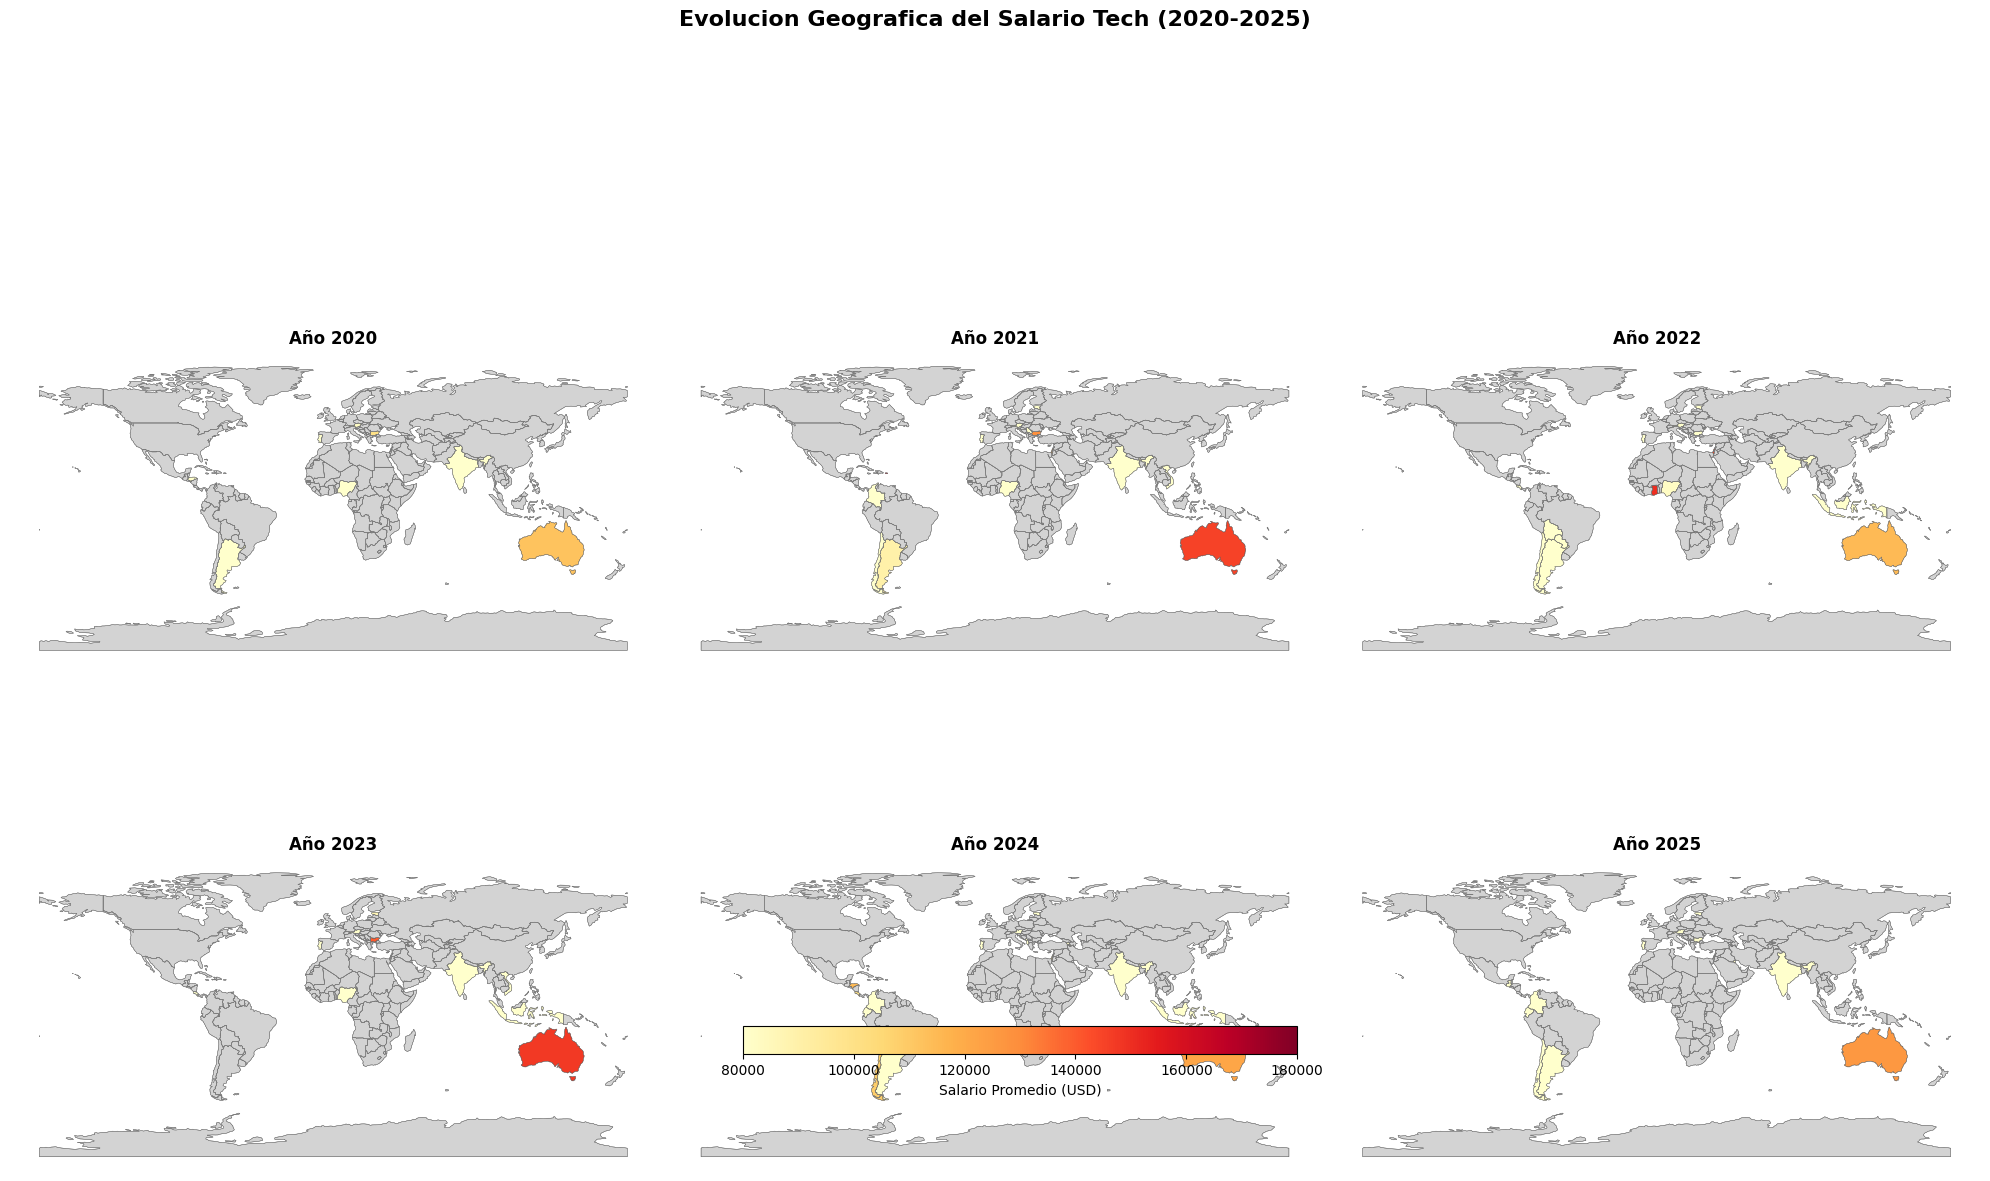

Mapas estaticos tambien generados para documentacion


In [48]:
print("\n" + "="*70)
print("1. EVOLUCION GEOGRAFICA DEL IMPACTO IA (2020-2025)")
print("="*70)

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Preparar datos para todos los años
years = sorted(df['work_year'].unique())
all_years_data = []

for year in years:
    year_data = df[df['work_year'] == year].groupby('employee_country_name').agg({
        'salary_in_usd': ['mean', 'median', 'size']
    }).reset_index()
    year_data.columns = ['country', 'avg_salary', 'median_salary', 'job_count']
    year_data['year'] = year
    all_years_data.append(year_data)

combined_data = pd.concat(all_years_data, ignore_index=True)

# Funcion automatica para mapear nombres de paises a codigos ISO
def get_iso_code(country_name):
    if not HAS_PYCOUNTRY:
        return None
    
    try:
        # Intento directo
        country = pycountry.countries.get(name=country_name)
        if country:
            return country.alpha_3
        
        # Busqueda fuzzy
        country = pycountry.countries.search_fuzzy(country_name)
        if country:
            return country[0].alpha_3
    except:
        pass
    
    # Mapeo manual para casos especiales
    # Mapeo manual para casos especiales (versión ampliada con español)
    manual_map = {
        # --- LOS 54 PAÍSES FALTANTES (de tu lista) ---
        'Afganistán': 'AFG',
        'Alemania': 'DEU',
        'Arabia Saudita': 'SAU',
        'Argelia': 'DZA',
        'Azerbaiyán': 'AZE',
        'Botsuana': 'BWA',
        'Brasil': 'BRA',
        'Bélgica': 'BEL',
        'Chipre': 'CYP',
        'Corea del Sur': 'KOR',
        'Croacia': 'HRV',
        'Egipto': 'EGY',
        'Emiratos Árabes Unidos': 'ARE',
        'Eslovaquia': 'SVK',
        'Eslovenia': 'SVN',
        'España': 'ESP',
        'Estados Unidos': 'USA',
        'Filipinas': 'PHL',
        'Finlandia': 'FIN',
        'Francia': 'FRA',
        'Grecia': 'GRC',
        'Hungría': 'HUN',
        'Irlanda': 'IRL',
        'Japón': 'JPN',
        'Jordania': 'JOR',
        'Kazajistán': 'KAZ',
        'Kenia': 'KEN',
        'Kirguistán': 'KGZ',
        'Letonia': 'LVA',
        'Lituania': 'LTU',
        'Luxemburgo': 'LUX',
        'Líbano': 'LBN',
        'Macedonia (ARYM)': 'MKD', # Antigua Rep. Yugoslava de Macedonia
        'Malasia': 'MYS',
        'Moldavia': 'MDA',
        'Noruega': 'NOR',
        'Nueva Zelanda': 'NZL',
        'Países Bajos': 'NLD',
        'Polonia': 'POL',
        'Reino Unido': 'GBR',
        'República Checa': 'CZE',
        'Ruanda': 'RWA',
        'Rumania': 'ROU',
        'Rusia': 'RUS',
        'Singapur': 'SGP',
        'Sudáfrica': 'ZAF',
        'Suecia': 'SWE',
        'Suiza': 'CHE',
        'Tailandia': 'THA',
        'Turquía': 'TUR',
        'Túnez': 'TUN',
        'Ucrania': 'UKR',
        'Yibuti': 'DJI',
        'Zimbabue': 'ZWE',

        # --- Otros países que ya tenías (por si acaso) ---
        'Argentina': 'ARG',
        'Australia': 'AUS',
        'Austria': 'AUT',
        'Bolivia': 'BOL',
        'Bosnia y Herzegovina': 'BIH',
        'Canadá': 'CAN',
        'Chile': 'CHL',
        'China': 'CHN',
        'Colombia': 'COL',
        'Dinamarca': 'DNK',
        'Estonia': 'EST',
        'India': 'IND',
        'Indonesia': 'IDN',
        'Irán': 'IRN',
        'Israel': 'ISR',
        'Italia': 'ITA',
        'Macedonia del Norte': 'MKD',
        'México': 'MEX',
        'Nigeria': 'NGA',
        'Perú': 'PER',
        'Portugal': 'PRT',
        'Siria': 'SYR',
        'Tanzania': 'TZA',
        'Venezuela': 'VEN',
        'Vietnam': 'VNM',
        
        # --- Casos en Inglés (del código original) ---
        'United States': 'USA',
        'United Kingdom': 'GBR',
        'South Korea': 'KOR',
        'Russia': 'RUS',
        'Czech Republic': 'CZE',
        'Bosnia and Herzegovina': 'BIH',
        'North Macedonia': 'MKD',
        'Moldova': 'MDA',
        'Laos': 'LAO'
    }
    
    return manual_map.get(country_name, None)

# Aplicar mapeo automatico
combined_data['iso_code'] = combined_data['country'].apply(get_iso_code)

# Reporte de paises sin codigo ISO
missing_iso = combined_data[combined_data['iso_code'].isna()]['country'].unique()
if len(missing_iso) > 0:
    print(f"\nADVERTENCIA: {len(missing_iso)} paises sin codigo ISO (no apareceran en el mapa):")
    for country in missing_iso[:10]:
        print(f"  - {country}")
    if len(missing_iso) > 10:
        print(f"  ... y {len(missing_iso)-10} mas")

# Filtrar solo paises con codigo ISO valido
combined_data_valid = combined_data[combined_data['iso_code'].notna()].copy()
print(f"\nPaises con codigo ISO valido: {combined_data_valid['country'].nunique()}/{combined_data['country'].nunique()}")

# Crear mapa interactivo con slider temporal
fig = px.choropleth(combined_data_valid,
                    locations='iso_code',
                    color='avg_salary',
                    hover_name='country',
                    hover_data={
                        'iso_code': False,
                        'avg_salary': ':,.0f',
                        'median_salary': ':,.0f',
                        'job_count': ':,',
                        'year': True
                    },
                    animation_frame='year',
                    color_continuous_scale='YlOrRd',
                    range_color=[80000, 180000],
                    labels={
                        'avg_salary': 'Salario Promedio',
                        'median_salary': 'Salario Mediana',
                        'job_count': 'Numero de Empleos',
                        'year': 'Año'
                    },
                    title='Evolucion Geografica del Salario Tech (2020-2025) - INTERACTIVO')

fig.update_layout(
    width=1400,
    height=700,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    )
)

fig.write_html('13_evolucion_geografica_interactiva.html')
fig.show()

print("Mapa interactivo generado: 13_evolucion_geografica_interactiva.html")
print("Abre el archivo HTML en tu navegador para interactuar")

# Version estatica tambien (para documentacion)
fig_static, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, year in enumerate(years):
    if idx < len(axes):
        ax = axes[idx]
        
        year_data = df[df['work_year'] == year].groupby('employee_country_name').agg({
            'salary_in_usd': ['mean', 'size']
        }).reset_index()
        year_data.columns = ['country', 'avg_salary', 'job_count']
        
        world_year = world.merge(year_data, left_on=country_col, right_on='country', how='left')
        
        world_year.boundary.plot(ax=ax, linewidth=0.3, color='gray')
        world_year.plot(column='avg_salary', ax=ax, cmap='YlOrRd',
                       edgecolor='black', linewidth=0.2,
                       legend=False, vmin=80000, vmax=180000,
                       missing_kwds={'color': 'lightgray'})
        
        ax.set_title(f'Año {year}', fontsize=12, fontweight='bold')
        ax.axis('off')

if len(years) < len(axes):
    fig_static.delaxes(axes[-1])

sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=80000, vmax=180000))
sm.set_array([])
cbar = fig_static.colorbar(sm, ax=axes, orientation='horizontal', 
                           fraction=0.03, pad=0.05, label='Salario Promedio (USD)')

fig_static.suptitle('Evolucion Geografica del Salario Tech (2020-2025)', 
                    fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig('13_evolucion_geografica_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

print("Mapas estaticos tambien generados para documentacion")


2. AUTOCORRELACION ESPACIAL ENTRE PAISES
Paises analizados: 14

Moran's I: 0.1626
Interpretacion: Existe AUTOCORRELACION ESPACIAL POSITIVA
(Paises cercanos tienden a tener salarios similares)


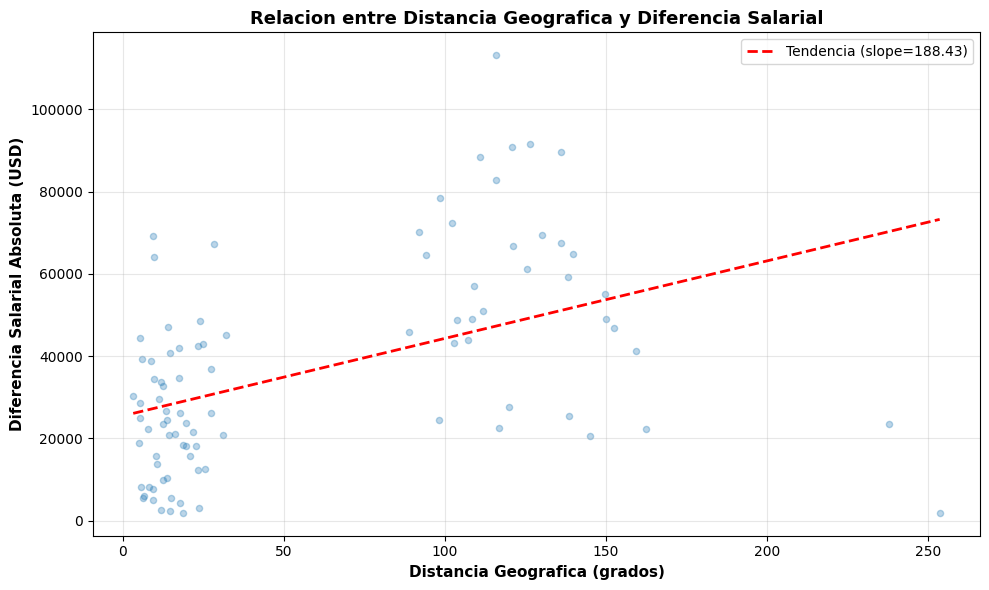

In [46]:
print("\n" + "="*70)
print("2. AUTOCORRELACION ESPACIAL ENTRE PAISES")
print("="*70)

# Calcular salario promedio por pais en Post-IA
salary_by_country = df[df['ai_period'] == 'Post-IA'].groupby('employee_country_name').agg({
    'salary_in_usd': 'mean',
    'employee_latitude': 'first',
    'employee_longitude': 'first'
}).reset_index()

# Filtrar paises con suficientes datos
country_counts = df[df['ai_period'] == 'Post-IA']['employee_country_name'].value_counts()
valid_countries = country_counts[country_counts >= 50].index
salary_by_country = salary_by_country[salary_by_country['employee_country_name'].isin(valid_countries)]

print(f"Paises analizados: {len(salary_by_country)}")

# Calcular matriz de distancias geograficas
coords = salary_by_country[['employee_latitude', 'employee_longitude']].values
dist_matrix = squareform(pdist(coords, metric='euclidean'))

# Crear matriz de pesos (inverso de distancia)
W = 1 / (dist_matrix + 1)
np.fill_diagonal(W, 0)

# Normalizar por fila
W = W / W.sum(axis=1, keepdims=True)

# Calcular Moran's I
salaries = salary_by_country['salary_in_usd'].values
salary_mean = salaries.mean()
z = salaries - salary_mean

numerator = np.sum(W * np.outer(z, z))
denominator = np.sum(z**2)
n = len(salaries)

morans_i = (n / np.sum(W)) * (numerator / denominator)

print(f"\nMoran's I: {morans_i:.4f}")
if morans_i > 0:
    print("Interpretacion: Existe AUTOCORRELACION ESPACIAL POSITIVA")
    print("(Paises cercanos tienden a tener salarios similares)")
elif morans_i < 0:
    print("Interpretacion: Existe AUTOCORRELACION ESPACIAL NEGATIVA")
    print("(Paises cercanos tienden a tener salarios diferentes)")
else:
    print("Interpretacion: NO hay autocorrelacion espacial")

# Visualizar correlacion entre distancia geografica y diferencia salarial
salary_diff = np.abs(np.subtract.outer(salaries, salaries))
dist_flat = dist_matrix[np.triu_indices(len(dist_matrix), k=1)]
diff_flat = salary_diff[np.triu_indices(len(salary_diff), k=1)]

# Sample para visualizacion
sample_size = min(1000, len(dist_flat))
sample_idx = np.random.choice(len(dist_flat), sample_size, replace=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(dist_flat[sample_idx], diff_flat[sample_idx], alpha=0.3, s=20)

# Linea de tendencia
z_poly = np.polyfit(dist_flat, diff_flat, 1)
p_poly = np.poly1d(z_poly)
x_trend = np.linspace(dist_flat.min(), dist_flat.max(), 100)
ax.plot(x_trend, p_poly(x_trend), "r--", linewidth=2, label=f'Tendencia (slope={z_poly[0]:.2f})')

ax.set_xlabel('Distancia Geografica (grados)', fontsize=11, fontweight='bold')
ax.set_ylabel('Diferencia Salarial Absoluta (USD)', fontsize=11, fontweight='bold')
ax.set_title('Relacion entre Distancia Geografica y Diferencia Salarial', 
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('14_autocorrelacion_espacial.png', dpi=300, bbox_inches='tight')
plt.show()

### CROSS-CORRELATION GEOGRAFICA (Lead/Lag entre regiones)


3. ANALISIS LEAD/LAG ENTRE REGIONES
Regiones con suficientes datos: ['Asia', 'Latin America']


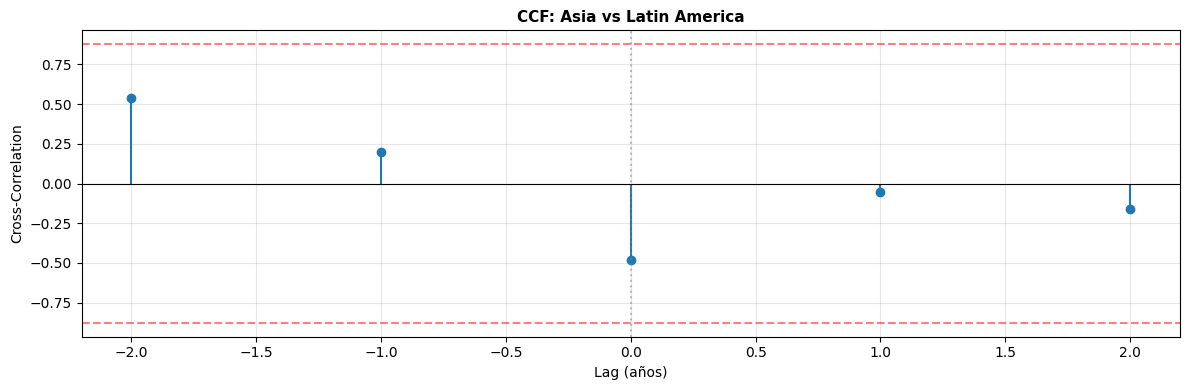


Interpretacion de Lead/Lag:
- Lag negativo: Region de referencia predice a la otra region
- Lag positivo: Otra region predice a la region de referencia
- Lag 0: Cambios ocurren simultaneamente


In [45]:
print("\n" + "="*70)
print("3. ANALISIS LEAD/LAG ENTRE REGIONES")
print("="*70)

# Crear series temporales por region
regions = {
    'North America': ['United States', 'Canada', 'Mexico'],
    'Europe': ['United Kingdom', 'Germany', 'France', 'Spain', 'Netherlands'],
    'Asia': ['India', 'China', 'Japan', 'Singapore', 'South Korea'],
    'Latin America': ['Brazil', 'Argentina', 'Chile', 'Colombia']
}

region_series = {}
for region, countries in regions.items():
    region_data = df[df['employee_country_name'].isin(countries)]
    if len(region_data) > 0:
        yearly_salary = region_data.groupby('work_year')['salary_in_usd'].mean()
        if len(yearly_salary) >= 4:
            region_series[region] = yearly_salary

print(f"Regiones con suficientes datos: {list(region_series.keys())}")

if len(region_series) >= 2:
    # Tomar region de referencia (la que tiene mas datos)
    reference_region = max(region_series.keys(), key=lambda k: len(region_series[k]))
    
    fig, axes = plt.subplots(len(region_series)-1, 1, 
                             figsize=(12, 4*(len(region_series)-1)))
    
    if len(region_series) == 2:
        axes = [axes]
    
    plot_idx = 0
    for region in region_series.keys():
        if region != reference_region:
            # Alinear series temporales
            s1 = region_series[reference_region]
            s2 = region_series[region]
            
            common_years = s1.index.intersection(s2.index)
            if len(common_years) >= 4:
                s1_aligned = s1[common_years].values
                s2_aligned = s2[common_years].values
                
                # Calcular CCF
                ccf_values = ccf(s1_aligned, s2_aligned, adjusted=False)
                max_lag = min(len(ccf_values)//2, 3)
                lags = np.arange(-max_lag, max_lag+1)
                ccf_subset = np.concatenate([ccf_values[len(ccf_values)//2-max_lag:len(ccf_values)//2],
                                            [ccf_values[len(ccf_values)//2]],
                                            ccf_values[len(ccf_values)//2+1:len(ccf_values)//2+max_lag+1]])
                
                # Plot
                axes[plot_idx].stem(lags, ccf_subset, basefmt=' ', 
                                   linefmt='C0-', markerfmt='C0o')
                
                # Bandas de confianza
                conf_bound = 1.96 / np.sqrt(len(common_years))
                axes[plot_idx].axhline(conf_bound, color='red', linestyle='--', alpha=0.5)
                axes[plot_idx].axhline(-conf_bound, color='red', linestyle='--', alpha=0.5)
                axes[plot_idx].axhline(0, color='black', linewidth=0.8)
                axes[plot_idx].axvline(0, color='gray', linestyle=':', alpha=0.5)
                
                axes[plot_idx].set_xlabel('Lag (años)', fontsize=10)
                axes[plot_idx].set_ylabel('Cross-Correlation', fontsize=10)
                axes[plot_idx].set_title(f'CCF: {reference_region} vs {region}', 
                                        fontsize=11, fontweight='bold')
                axes[plot_idx].grid(True, alpha=0.3)
                
                # Encontrar lag con maxima correlacion
                max_corr_idx = np.argmax(np.abs(ccf_subset))
                max_lag_val = lags[max_corr_idx]
                max_corr_val = ccf_subset[max_corr_idx]
                
                if abs(max_corr_val) > conf_bound:
                    if max_lag_val < 0:
                        interpretation = f"{reference_region} LIDERA por {abs(max_lag_val)} año(s)"
                    elif max_lag_val > 0:
                        interpretation = f"{region} LIDERA por {max_lag_val} año(s)"
                    else:
                        interpretation = "Correlacion CONTEMPORANEA"
                    
                    axes[plot_idx].text(0.02, 0.98, interpretation, 
                                       transform=axes[plot_idx].transAxes,
                                       fontsize=9, verticalalignment='top',
                                       bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
                
                plot_idx += 1
    
    plt.tight_layout()
    plt.savefig('15_ccf_regiones_lead_lag.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nInterpretacion de Lead/Lag:")
    print("- Lag negativo: Region de referencia predice a la otra region")
    print("- Lag positivo: Otra region predice a la region de referencia")
    print("- Lag 0: Cambios ocurren simultaneamente")
else:
    print("No hay suficientes regiones con datos para CCF")

### HEATMAP: CORRELACION ENTRE PAISES (Top 15)


4. MATRIZ DE CORRELACION ENTRE PAISES


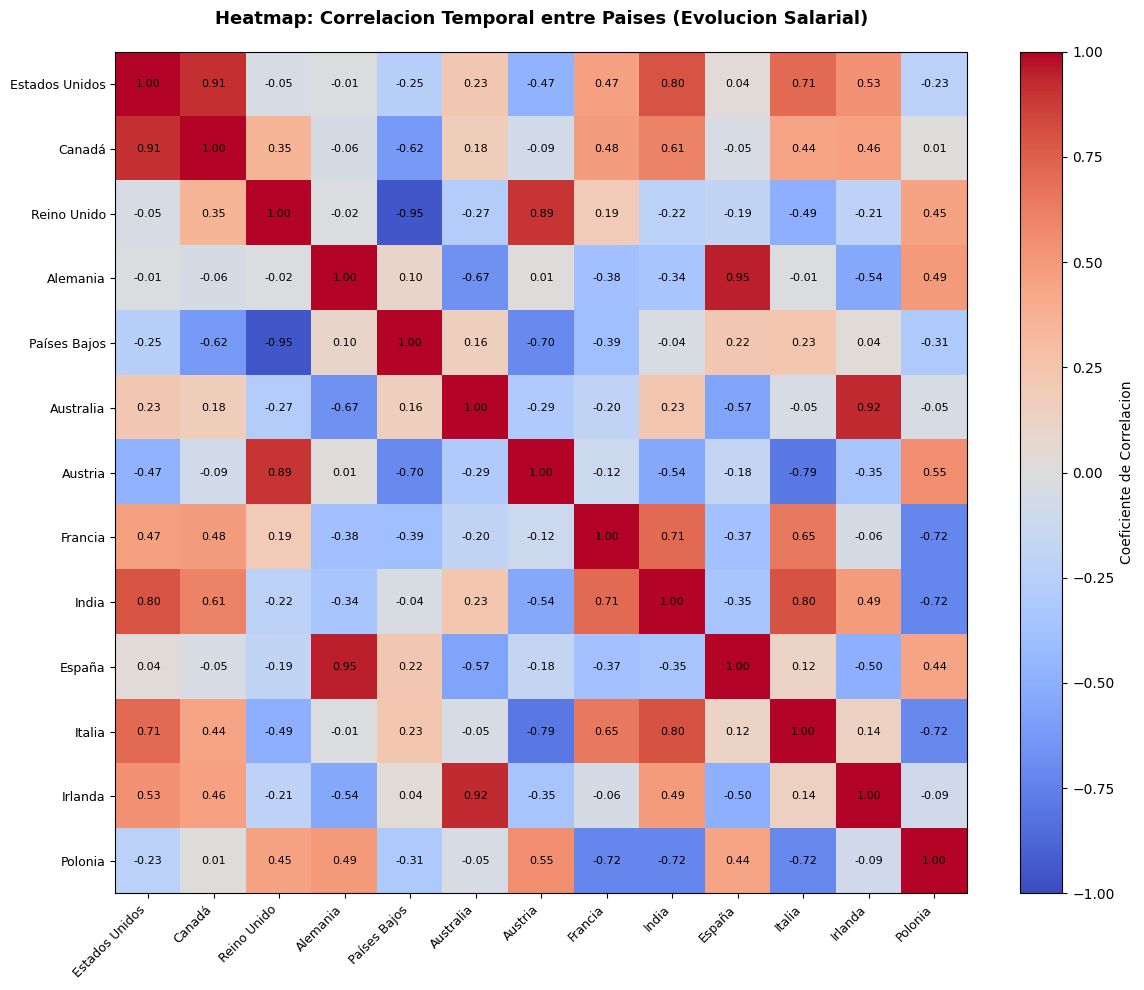


Top 10 pares de paises con mayor correlacion:
  1. Alemania <-> España: 0.947
  2. Reino Unido <-> Países Bajos: -0.946
  3. Australia <-> Irlanda: 0.922
  4. Estados Unidos <-> Canadá: 0.907
  5. Reino Unido <-> Austria: 0.895
  6. India <-> Italia: 0.798
  7. Estados Unidos <-> India: 0.795
  8. Austria <-> Italia: -0.794
  9. India <-> Polonia: -0.724
  10. Francia <-> Polonia: -0.722


In [44]:
print("\n" + "="*70)
print("4. MATRIZ DE CORRELACION ENTRE PAISES")
print("="*70)

# Crear series temporales por pais (top 15)
top_countries = df['employee_country_name'].value_counts().head(15).index

country_year_matrix = []
country_names = []

for country in top_countries:
    country_data = df[df['employee_country_name'] == country]
    yearly_salary = country_data.groupby('work_year')['salary_in_usd'].mean()
    
    if len(yearly_salary) >= 4:
        country_year_matrix.append(yearly_salary.values)
        country_names.append(country)

if len(country_names) >= 3:
    # Crear matriz de correlacion
    corr_matrix = np.corrcoef(country_year_matrix)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    
    # Etiquetas
    ax.set_xticks(np.arange(len(country_names)))
    ax.set_yticks(np.arange(len(country_names)))
    ax.set_xticklabels(country_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(country_names, fontsize=9)
    
    # Valores en celdas
    for i in range(len(country_names)):
        for j in range(len(country_names)):
            text = ax.text(j, i, f'{corr_matrix[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=8)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, label='Coeficiente de Correlacion')
    
    ax.set_title('Heatmap: Correlacion Temporal entre Paises (Evolucion Salarial)', 
                 fontsize=13, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('16_heatmap_correlacion_paises.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Encontrar pares con mayor correlacion
    corr_flat = corr_matrix[np.triu_indices(len(corr_matrix), k=1)]
    pairs = [(country_names[i], country_names[j], corr_matrix[i,j]) 
             for i in range(len(country_names)) 
             for j in range(i+1, len(country_names))]
    pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
    
    print("\nTop 10 pares de paises con mayor correlacion:")
    for i, (c1, c2, corr) in enumerate(pairs_sorted[:10], 1):
        print(f"  {i}. {c1} <-> {c2}: {corr:.3f}")
else:
    print("No hay suficientes paises con datos para matriz de correlacion")

### DIFUSION GEOGRAFICA: Early vs Late Adopters


5. EARLY vs LATE ADOPTERS DEL IMPACTO IA


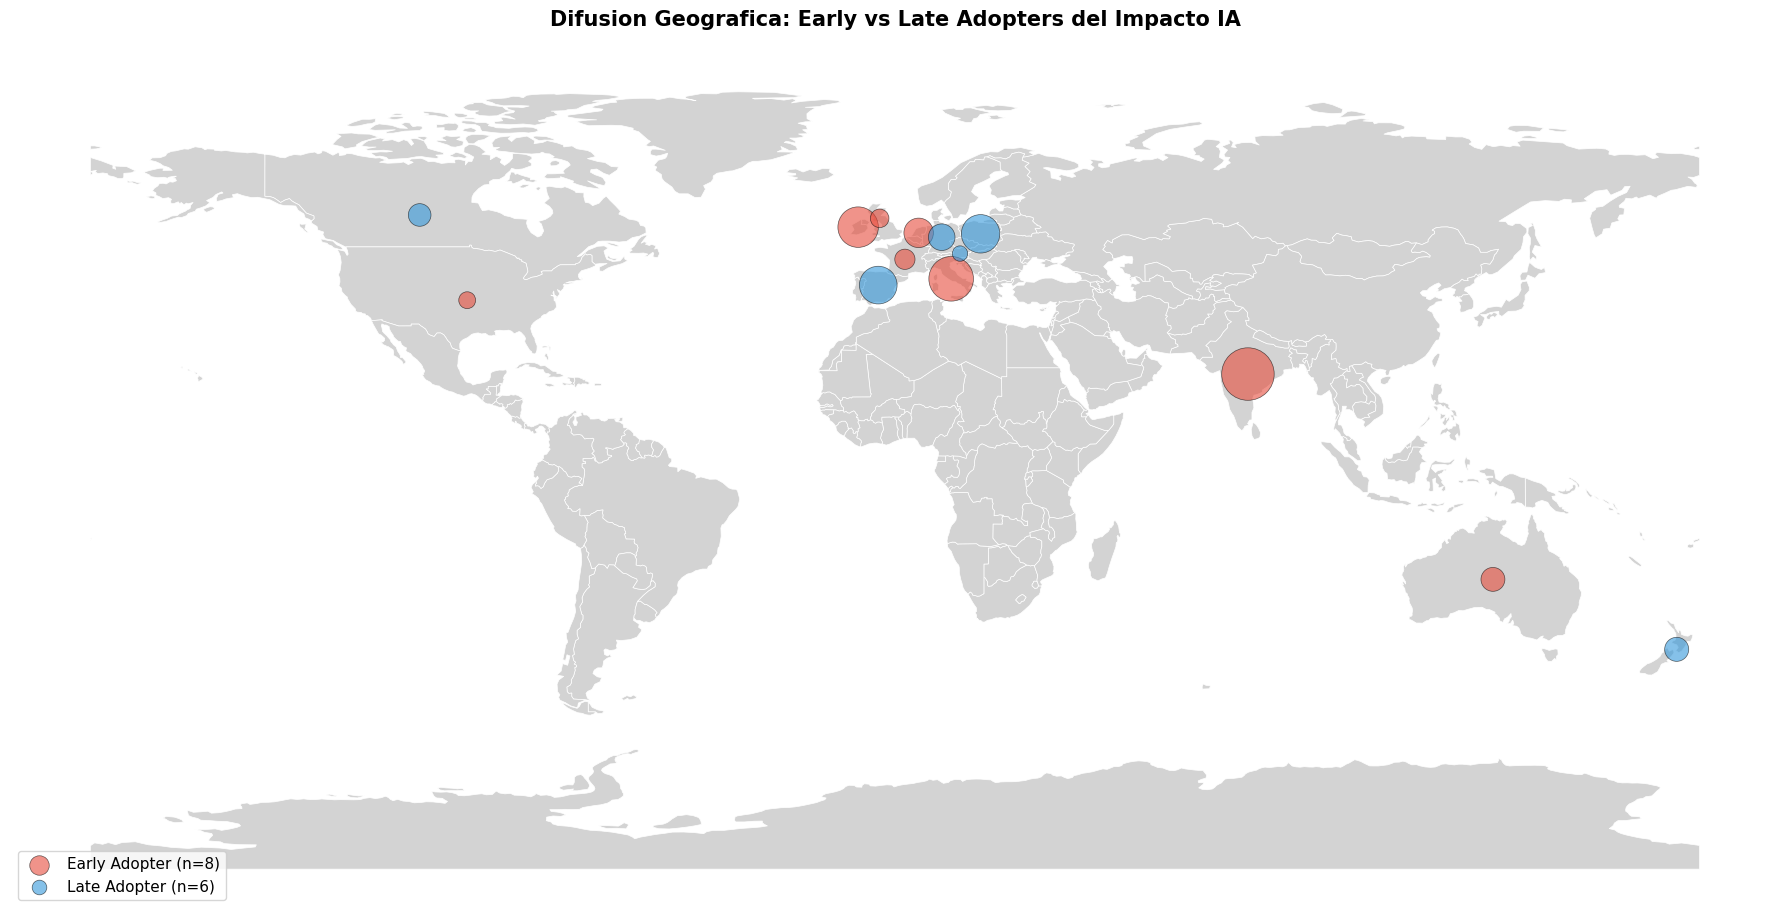


Median year (threshold): 2022
Paises analizados: 14
Early Adopter: 8 paises (57.1%)
Late Adopter: 6 paises (42.9%)

Top 5 Early Adopters por crecimiento:
  India: Pico en 2021 (143.0%)
  Italia: Pico en 2021 (103.3%)
  Irlanda: Pico en 2021 (85.1%)
  Países Bajos: Pico en 2021 (45.1%)
  Australia: Pico en 2021 (29.6%)

Top 5 Late Adopters por crecimiento:
  Polonia: Pico en 2023 (76.6%)
  España: Pico en 2024 (73.6%)
  Alemania: Pico en 2024 (36.7%)
  Nueva Zelanda: Pico en 2023 (30.0%)
  Canadá: Pico en 2023 (26.6%)

Archivos generados:
  - 17_early_late_adopters.png (estatico)
  - 17_early_late_adopters_interactivo.html (interactivo)


In [43]:
print("\n" + "="*70)
print("5. EARLY vs LATE ADOPTERS DEL IMPACTO IA")
print("="*70)

# Parametros dinamicos
MIN_RECORDS_PER_COUNTRY = 50  # Ajustable segun dataset
MIN_YEARS_REQUIRED = 4        # Minimo de años para calcular tendencia

# Calcular cuando cada pais alcanzo su pico de crecimiento salarial
country_growth_timing = []

for country in df['employee_country_name'].unique():
    country_data = df[df['employee_country_name'] == country]
    
    if len(country_data) >= MIN_RECORDS_PER_COUNTRY:
        yearly_salary = country_data.groupby('work_year')['salary_in_usd'].mean()
        
        if len(yearly_salary) >= MIN_YEARS_REQUIRED:
            # Año de mayor crecimiento year-over-year
            returns = yearly_salary.pct_change().dropna()
            
            if len(returns) > 0:
                peak_year = returns.idxmax()
                peak_growth = returns.max() * 100
                
                # Obtener coordenadas
                lat = country_data['employee_latitude'].iloc[0]
                lon = country_data['employee_longitude'].iloc[0]
                
                country_growth_timing.append({
                    'country': country,
                    'peak_year': int(peak_year),
                    'peak_growth': peak_growth,
                    'latitude': lat,
                    'longitude': lon
                })

growth_timing_df = pd.DataFrame(country_growth_timing)

if len(growth_timing_df) > 0:
    # Clasificar early vs late adopters (dinamico basado en mediana)
    median_year = growth_timing_df['peak_year'].median()
    growth_timing_df['adopter_type'] = growth_timing_df['peak_year'].apply(
        lambda x: 'Early Adopter' if x <= median_year else 'Late Adopter'
    )
    
    # VERSION ESTATICA
    fig, ax = plt.subplots(1, 1, figsize=(18, 10))
    
    # Mapa base
    world.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5)
    
    # Colores dinamicos
    colors = {'Early Adopter': '#e74c3c', 'Late Adopter': '#3498db'}
    
    for adopter_type in growth_timing_df['adopter_type'].unique():
        subset = growth_timing_df[growth_timing_df['adopter_type'] == adopter_type]
        ax.scatter(subset['longitude'], subset['latitude'],
                  s=subset['peak_growth']*10, c=colors[adopter_type],
                  alpha=0.6, edgecolors='black', linewidth=0.5,
                  label=f"{adopter_type} (n={len(subset)})")
    
    ax.legend(loc='lower left', fontsize=11, frameon=True, markerscale=0.5)
    ax.set_title('Difusion Geografica: Early vs Late Adopters del Impacto IA', 
                 fontsize=15, fontweight='bold', pad=20)
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('17_early_late_adopters.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # VERSION INTERACTIVA CON PLOTLY
    growth_timing_df['iso_code'] = growth_timing_df['country'].apply(get_iso_code)
    
    fig_interactive = px.scatter_geo(growth_timing_df,
                                    lat='latitude',
                                    lon='longitude',
                                    color='adopter_type',
                                    size='peak_growth',
                                    hover_name='country',
                                    hover_data={
                                        'peak_year': True,
                                        'peak_growth': ':.1f',
                                        'latitude': False,
                                        'longitude': False,
                                        'adopter_type': True,
                                        'iso_code': False
                                    },
                                    color_discrete_map=colors,
                                    size_max=40,
                                    projection='natural earth',
                                    title='Early vs Late Adopters del Impacto IA - INTERACTIVO',
                                    labels={
                                        'peak_year': 'Año Pico',
                                        'peak_growth': 'Crecimiento (%)',
                                        'adopter_type': 'Tipo de Adopcion'
                                    })
    
    fig_interactive.update_layout(
        width=1400,
        height=700,
        geo=dict(
            showframe=False,
            showcoastlines=True,
            coastlinecolor='RebeccaPurple',
            showland=True,
            landcolor='lightgray'
        )
    )
    
    fig_interactive.show()
    
    # Estadisticas dinamicas
    print(f"\nMedian year (threshold): {median_year:.0f}")
    print(f"Paises analizados: {len(growth_timing_df)}")
    
    for adopter_type in growth_timing_df['adopter_type'].unique():
        count = len(growth_timing_df[growth_timing_df['adopter_type'] == adopter_type])
        pct = count / len(growth_timing_df) * 100
        print(f"{adopter_type}: {count} paises ({pct:.1f}%)")
    
    # Top adopters por tipo
    top_n = min(5, len(growth_timing_df) // 2)
    
    for adopter_type in growth_timing_df['adopter_type'].unique():
        print(f"\nTop {top_n} {adopter_type}s por crecimiento:")
        subset = growth_timing_df[growth_timing_df['adopter_type'] == adopter_type]
        top = subset.nlargest(top_n, 'peak_growth')
        for idx, row in top.iterrows():
            print(f"  {row['country']}: Pico en {row['peak_year']} ({row['peak_growth']:.1f}%)")
    
    print("\nArchivos generados:")
    print("  - 17_early_late_adopters.png (estatico)")
    print("  - 17_early_late_adopters_interactivo.html (interactivo)")
else:
    print(f"No hay suficientes datos para analisis de adopcion")
    print(f"Se requieren paises con {MIN_RECORDS_PER_COUNTRY}+ registros y {MIN_YEARS_REQUIRED}+ años de datos")
